# Mouse Neural Activity Integrated Analysis


## Table of Contents

- [0. Runtime and Imports](#sec-0)
- [1. Dataset and Output Paths](#sec-1)
- [2. Fluorescence Preprocessing](#sec-2)
- [2.1 RR Distribution and Population Response](#sec-21)
- [2.2 Timepoint Classification and Shuffled Baseline](#sec-22)
- [3. Spike Preprocessing and Network Construction](#sec-3)
- [3.1 Network Metrics Visualization](#sec-31)
- [4. Trial Aggregation and Class Balancing](#sec-4)
- [5. Neural Pattern Visualization](#sec-5)
- [6. RSM and Entropy](#sec-6)
- [7. Class-wise RR Selection](#sec-7)
- [8. Class-RR vs Other-RR](#sec-8)
- [9. Strong vs Weak Connectivity](#sec-9)
- [10. Export and Report Generation](#sec-10)


<a id="sec-0"></a>
## 0. Runtime and Imports

Import analysis functions and plotting libraries.


In [42]:
# 导入必要的库
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data, rr_selection_class
from brainnetwork import classify_by_timepoints, FI_by_timepoints_v2, FI_by_neuron_count
from brainnetwork import construct_correlation_network, compute_network_metrics_by_class
from brainnetwork.visualization import *
# %% 可视化相关函数定义
from tifffile import imread 
import numpy as np
import pandas as pd
import scipy.stats as stats


<a id="sec-1"></a>
## 1. Dataset and Output Paths

Select one mouse dataset and initialize output directories.


In [43]:
base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_paths = ["M21_1107", "M71_1024", "M73_1128", "M77_1031", "M77_1107", "M78_1017", "M79_1128", "M91_1017"]
idx = 2 # Change this index to select different datasets
data_path = base_dir + data_paths[idx] # 'M77_1031'
print(f"Processing data from: {data_path}")
save_dir = "../results/" + data_paths[idx] 

data_out_dir = os.path.join(save_dir, "data")
fig_out_dir = os.path.join(save_dir, "figures")

os.makedirs(data_out_dir, exist_ok=True)
os.makedirs(fig_out_dir, exist_ok=True)

Processing data from: /beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/M73_1128


## Baseline Response and Encoding

This section summarizes baseline response characteristics and stimulus encoding performance.


<a id="sec-2"></a>
## 2. Fluorescence Preprocessing

Load fluorescence data, segment trials, and prepare labels.


In [44]:
neuron_data_flo, neuron_pos_flo, start_edges_flo, stimulus_data_flo = load_data(data_path, data_type='fluorescence')
segments_flo, labels_flo, neuron_pos_rr = preprocess_data(
    neuron_data_flo,
    neuron_pos_flo,
    start_edges_flo,
    stimulus_data_flo,
)

原始神经数据形状: (8402, 38319)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 755 个 RR 神经元
  - 类别 2 贡献了 914 个 RR 神经元
  - 类别 3 贡献了 695 个 RR 神经元
三类并集后共筛选出 1395 个唯一 RR 神经元


<a id="sec-21"></a>
### 2.1 RR Distribution and Population Response

Visualize RR neuron spatial distribution and condition-averaged responses.


<tifffile.TiffPages @8> invalid page offset 1531619506


Error occurred while plotting RR distribution for spike data: failed to read 1531619250 bytes, got 53739264


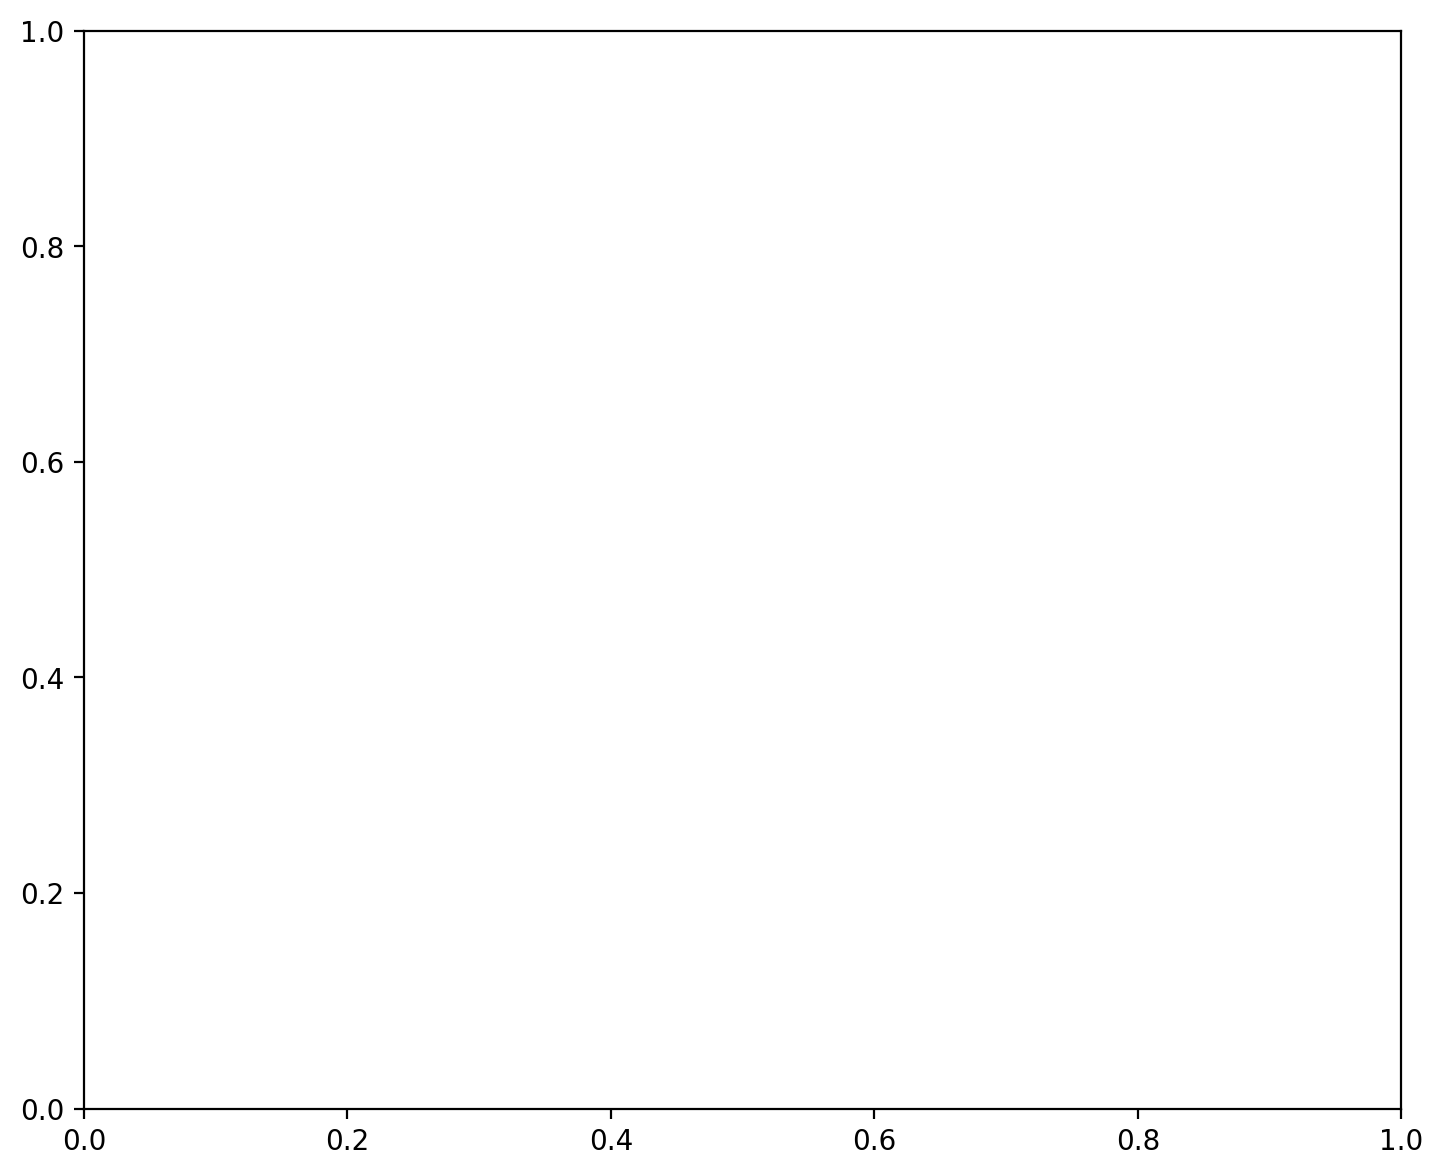

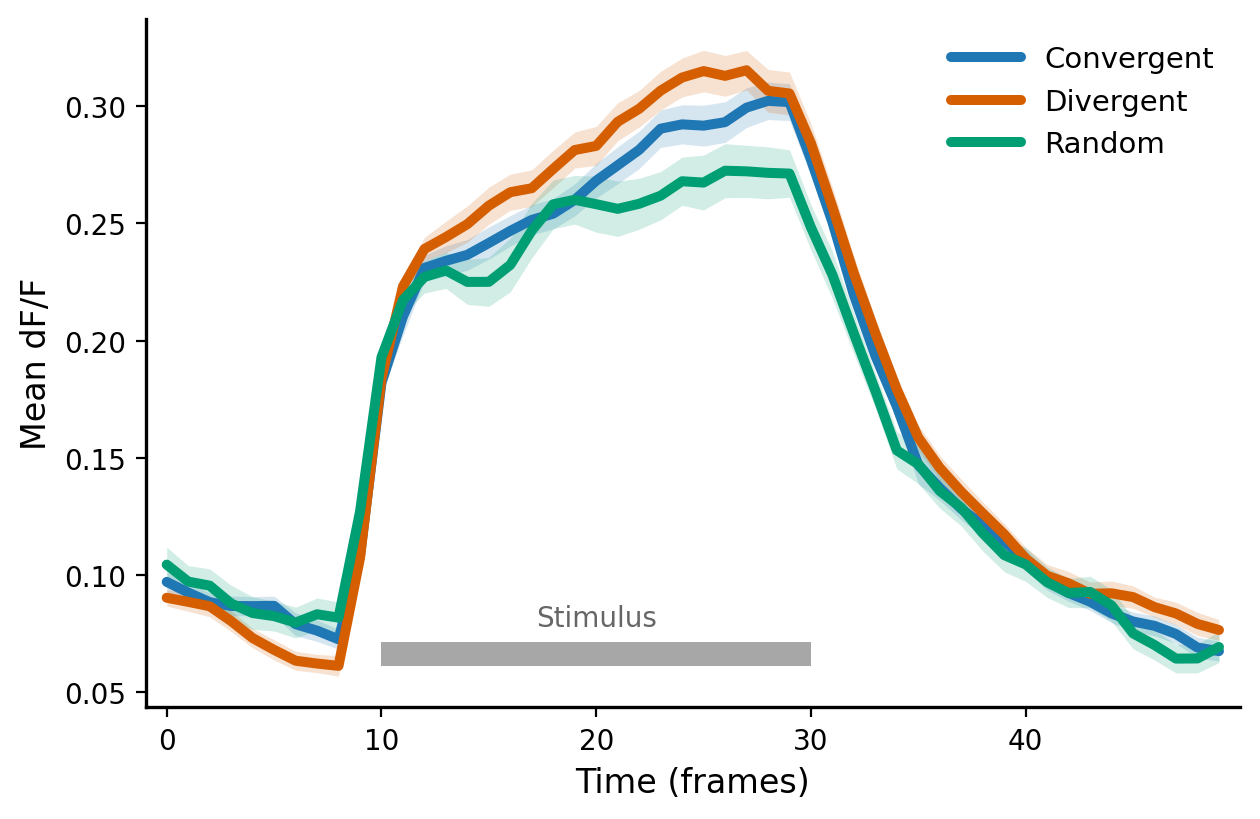

In [45]:
try:
    rr_distribution_plot_pretty(neuron_pos_flo, neuron_pos_rr, data_path, gamma=1.1, fig_out_dir=fig_out_dir)
except Exception as e:
    print(f"Error occurred while plotting RR distribution for spike data: {e}")

plot_rr_population_average_pretty(segments_flo, labels_flo, fig_out_dir=fig_out_dir)

<a id="sec-22"></a>
### 2.2 Timepoint Classification and Shuffled Baseline

Compare classification accuracy against a label-shuffled baseline.


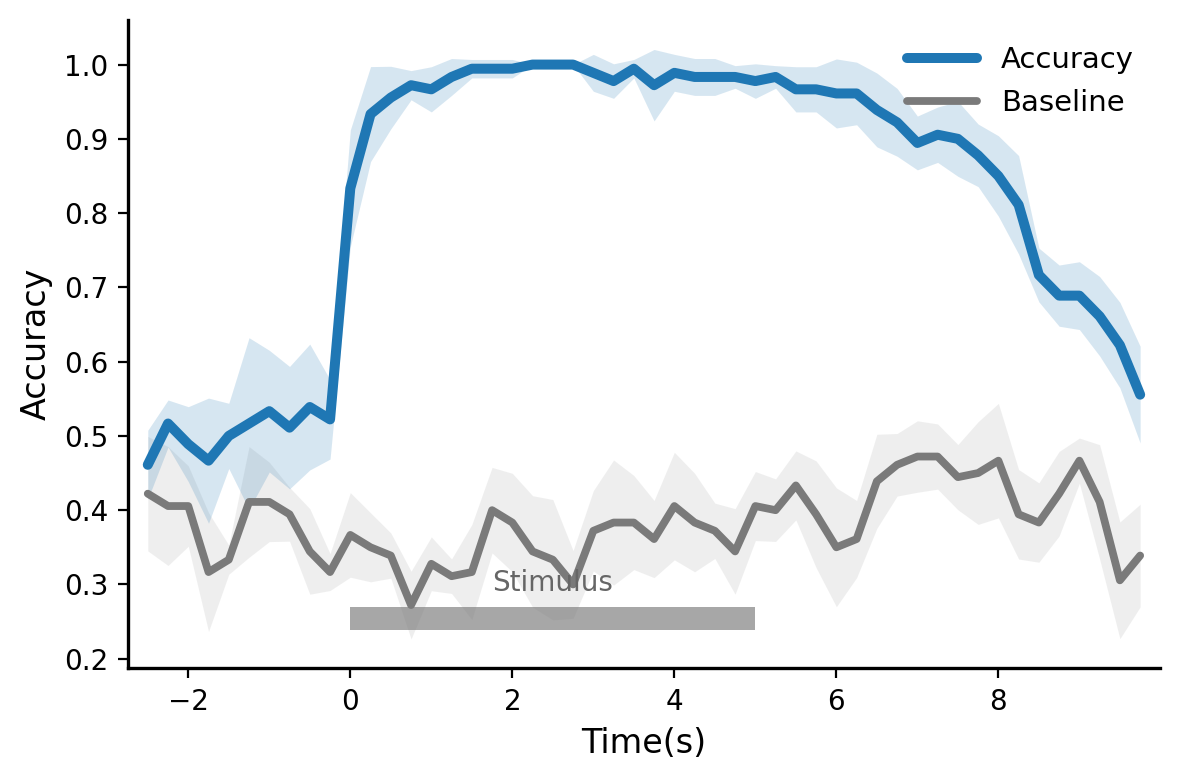

In [46]:
accuracies, time_points, accuracy_std, n_folds = classify_by_timepoints(segments_flo, labels_flo)

# 进行标签随机打乱的分类分析，作为基线比较
labels_shuffled = np.random.permutation(labels_flo)
accuracies_shu, time_points_shu, accuracy_std_shu, n_folds_shu = classify_by_timepoints(segments_flo, labels_shuffled)



plot_accuracy(time_points=time_points, accuracies=accuracies, baseline=accuracies_shu, accuracy_std=accuracy_std, baseline_std=accuracy_std_shu, save_path=os.path.join(fig_out_dir, "classification_accuracy.png"))

<a id="sec-3"></a>
## 3. Spike Preprocessing and Network Construction

Load spike data and compute class-wise functional network metrics.


In [47]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
    )

nx_result = compute_network_metrics_by_class(segments_spi, labels_spi, neuron_pos_spi, do_bootstrap=False)

原始神经数据形状: (8402, 38247)
使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 218 个 RR 神经元
  - 类别 2 贡献了 312 个 RR 神经元
  - 类别 3 贡献了 170 个 RR 神经元
三类并集后共筛选出 513 个唯一 RR 神经元


<a id="sec-31"></a>
### 3.1 Network Metrics Visualization

Plot pairwise correlation distribution and graph-theoretic metrics.


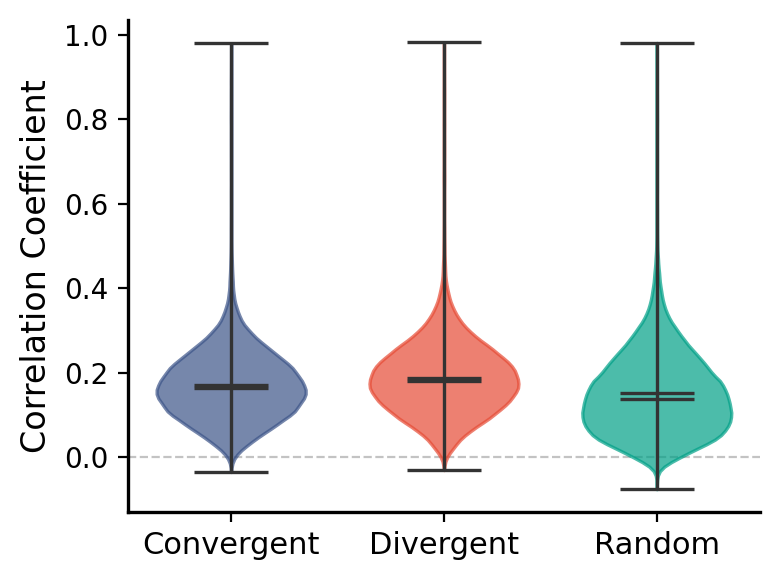

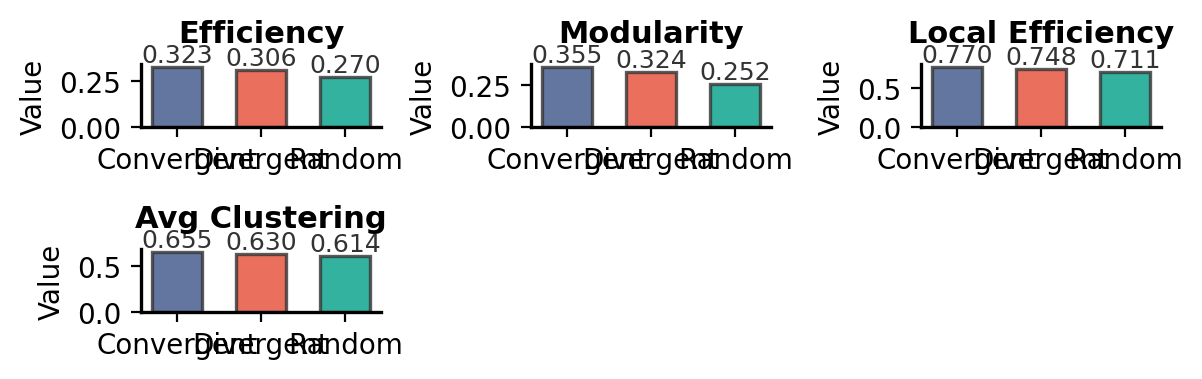

In [48]:
plot_correlation_violin_optim(nx_result, fig_out_dir=fig_out_dir)
plot_network_metrics_bars_optim(nx_result, metrics=['efficiency', 'modularity', 'local_efficiency', 'avg_clustering'], figsize=(6,2), fig_out_dir=fig_out_dir)


## 3.2 Weak-Connection Graph Analysis

Compare graph-theoretic metrics between strongest and weakest connections using matched edge density.


[*] Strong-vs-weak graph metrics saved to: ../results/M73_1128/data/network_metrics_strong_vs_weak.csv


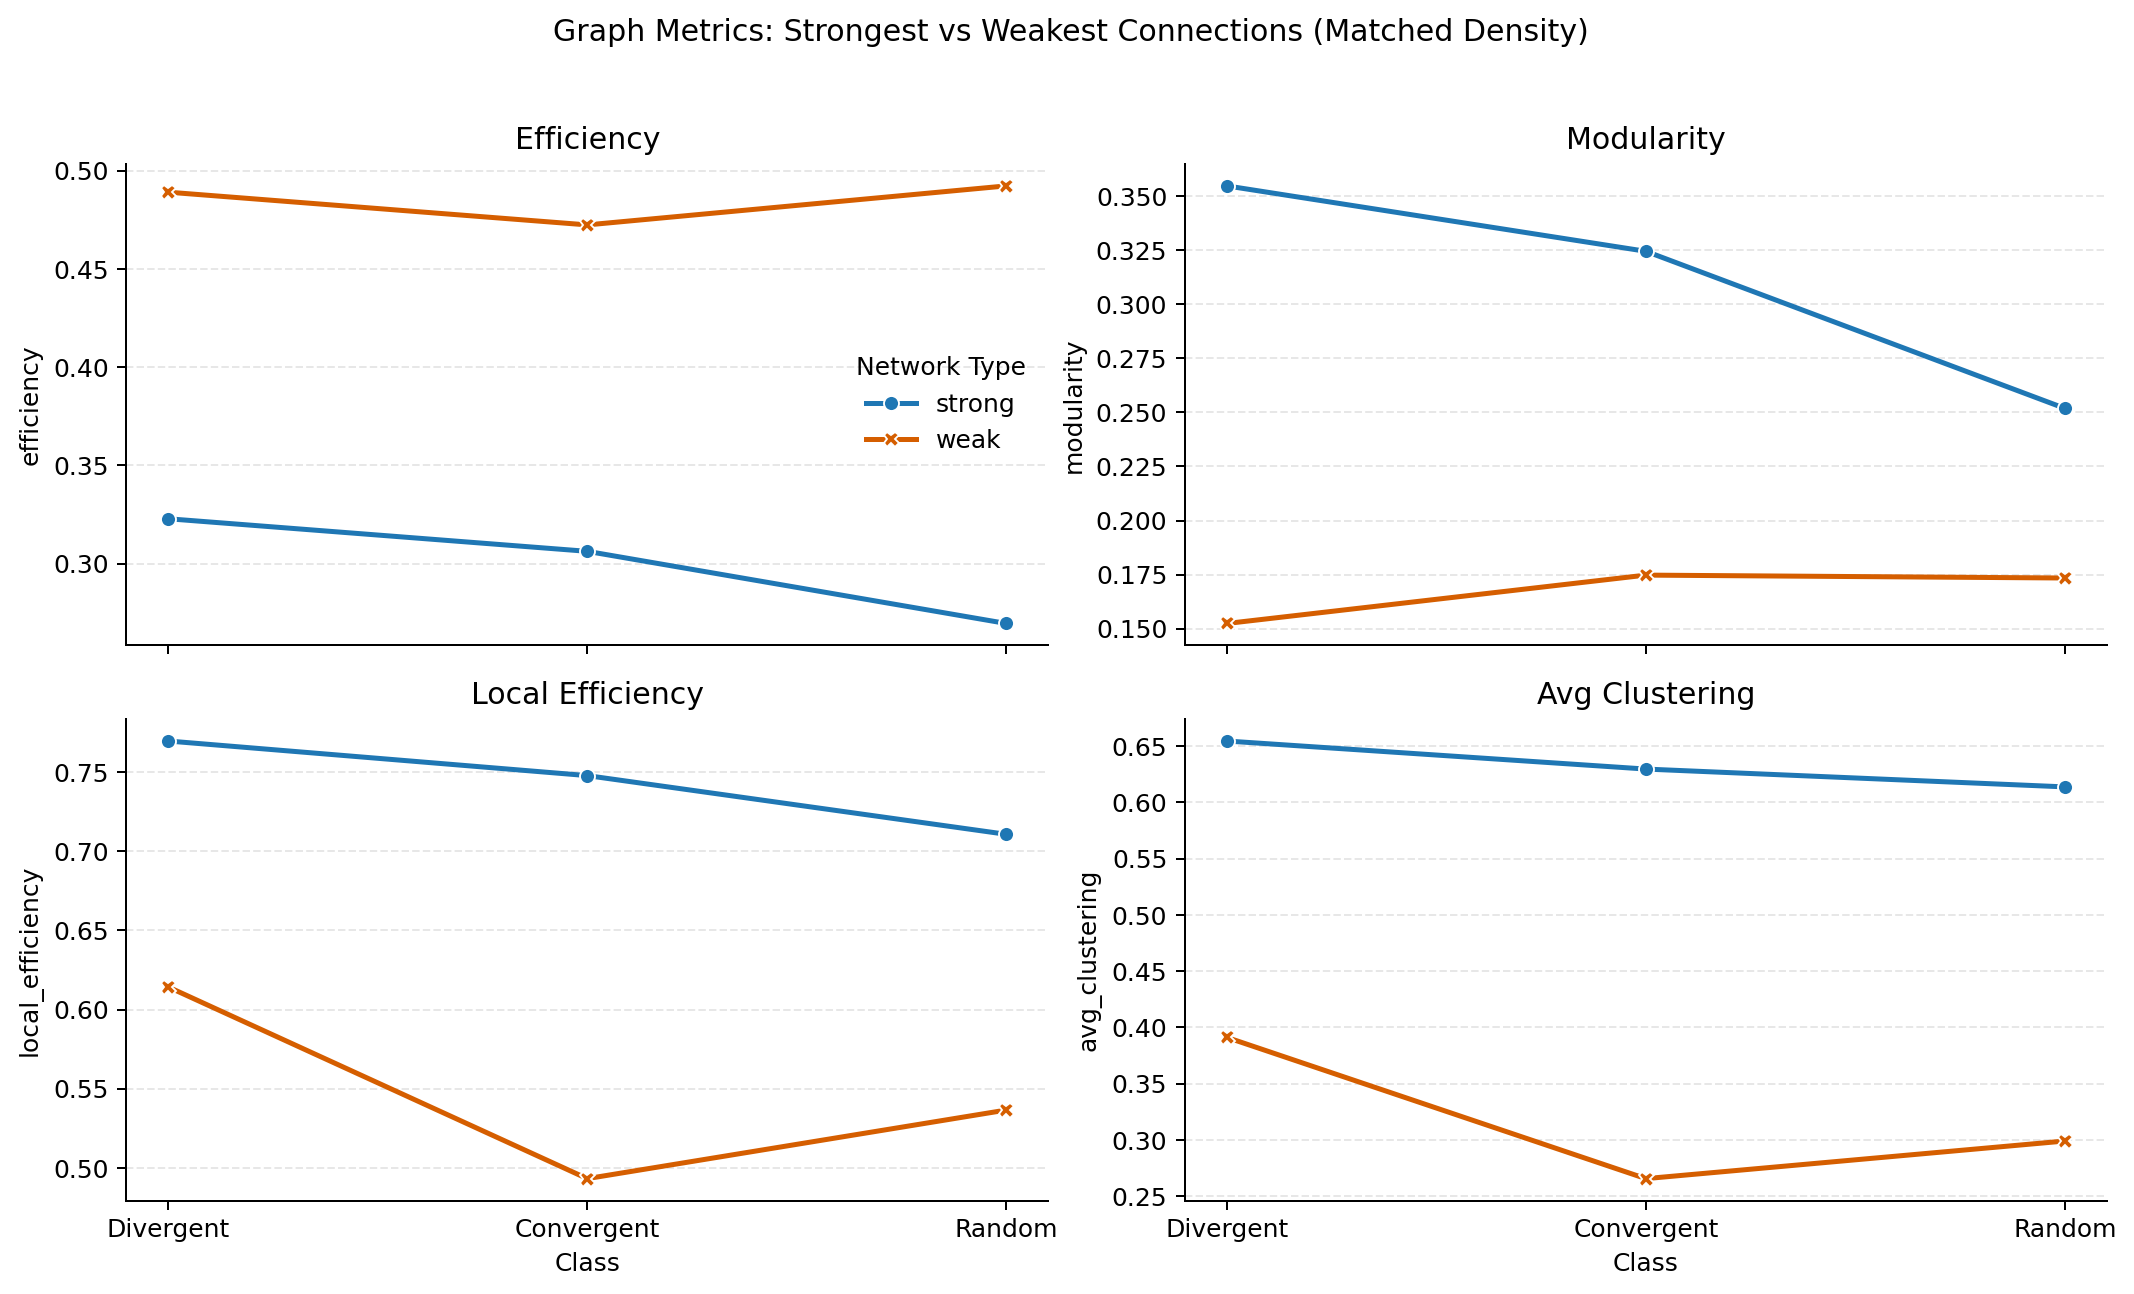

In [49]:

import networkx as nx
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def build_rank_graph_from_corr(corr_matrix, frac=0.05, mode="strong", weighted=False):
    """Build a graph by selecting strongest or weakest raw-correlation edges."""
    corr = np.asarray(corr_matrix, dtype=float)
    n = corr.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))

    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            v = float(corr[i, j])
            edges.append((v, i, j))

    edges.sort(key=lambda x: x[0], reverse=True)  # high -> low
    k = max(1, int(np.floor(frac * len(edges))))

    if mode == "strong":
        selected = edges[:k]
    elif mode == "weak":
        selected = edges[-k:]
    else:
        raise ValueError("mode must be 'strong' or 'weak'")

    for v, i, j in selected:
        if weighted:
            G.add_edge(i, j, weight=v)
        else:
            G.add_edge(i, j)

    return G


def compute_graph_metrics(G):
    if G.number_of_edges() == 0:
        return {
            "efficiency": 0.0,
            "modularity": 0.0,
            "local_efficiency": 0.0,
            "avg_clustering": 0.0,
            "density": 0.0,
            "n_edges": 0,
        }

    communities = list(nx.algorithms.community.greedy_modularity_communities(G))
    modularity = nx.algorithms.community.modularity(G, communities) if communities else 0.0

    return {
        "efficiency": float(nx.global_efficiency(G)),
        "modularity": float(modularity),
        "local_efficiency": float(nx.local_efficiency(G)) if G.number_of_nodes() > 1 else 0.0,
        "avg_clustering": float(nx.average_clustering(G)),
        "density": float(nx.density(G)),
        "n_edges": int(G.number_of_edges()),
    }


edge_frac = 0.05  # keep consistent with current strong-network setting
rows = []
for cls in sorted(nx_result):
    corr_matrix = np.asarray(nx_result[cls]["corr_matrix"], dtype=float)
    class_name = label_names.get(cls, str(cls)) if "label_names" in globals() else str(cls)

    for mode in ["strong", "weak"]:
        G = build_rank_graph_from_corr(corr_matrix, frac=edge_frac, mode=mode, weighted=False)
        metrics = compute_graph_metrics(G)
        rows.append({
            "Class_ID": cls,
            "Class_Name": class_name,
            "Network_Type": mode,
            "Edge_Fraction": edge_frac,
            **metrics,
        })


df_topology_sw = pd.DataFrame(rows)

# Save tabular results
csv_path = os.path.join(data_out_dir, "network_metrics_strong_vs_weak.csv")
df_topology_sw.to_csv(csv_path, index=False)
print(f"[*] Strong-vs-weak graph metrics saved to: {csv_path}")

# Plot line comparison for key graph metrics
metrics_to_plot = ["efficiency", "modularity", "local_efficiency", "avg_clustering"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=180, sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    sns.lineplot(
        data=df_topology_sw,
        x="Class_Name",
        y=metric,
        hue="Network_Type",
        style="Network_Type",
        markers=True,
        dashes=False,
        linewidth=2,
        palette={"strong": "#1F77B4", "weak": "#D55E00"},
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Class")
    ax.set_ylabel(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# keep one legend only
for ax in axes[1:]:
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, frameon=False, title="Network Type")

fig.suptitle("Graph Metrics: Strongest vs Weakest Connections (Matched Density)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, "network_metrics_strong_vs_weak_line.png"), dpi=300, bbox_inches="tight")
plt.show()



## 3.3 Threshold-based Graph Analysis

Build strong/weak graphs using fixed raw-correlation thresholds: strong >= 0.35, weak <= 0.10.


[*] Threshold-based graph metrics saved to: ../results/M73_1128/data/network_metrics_threshold_strong0.35_weak0.10.csv


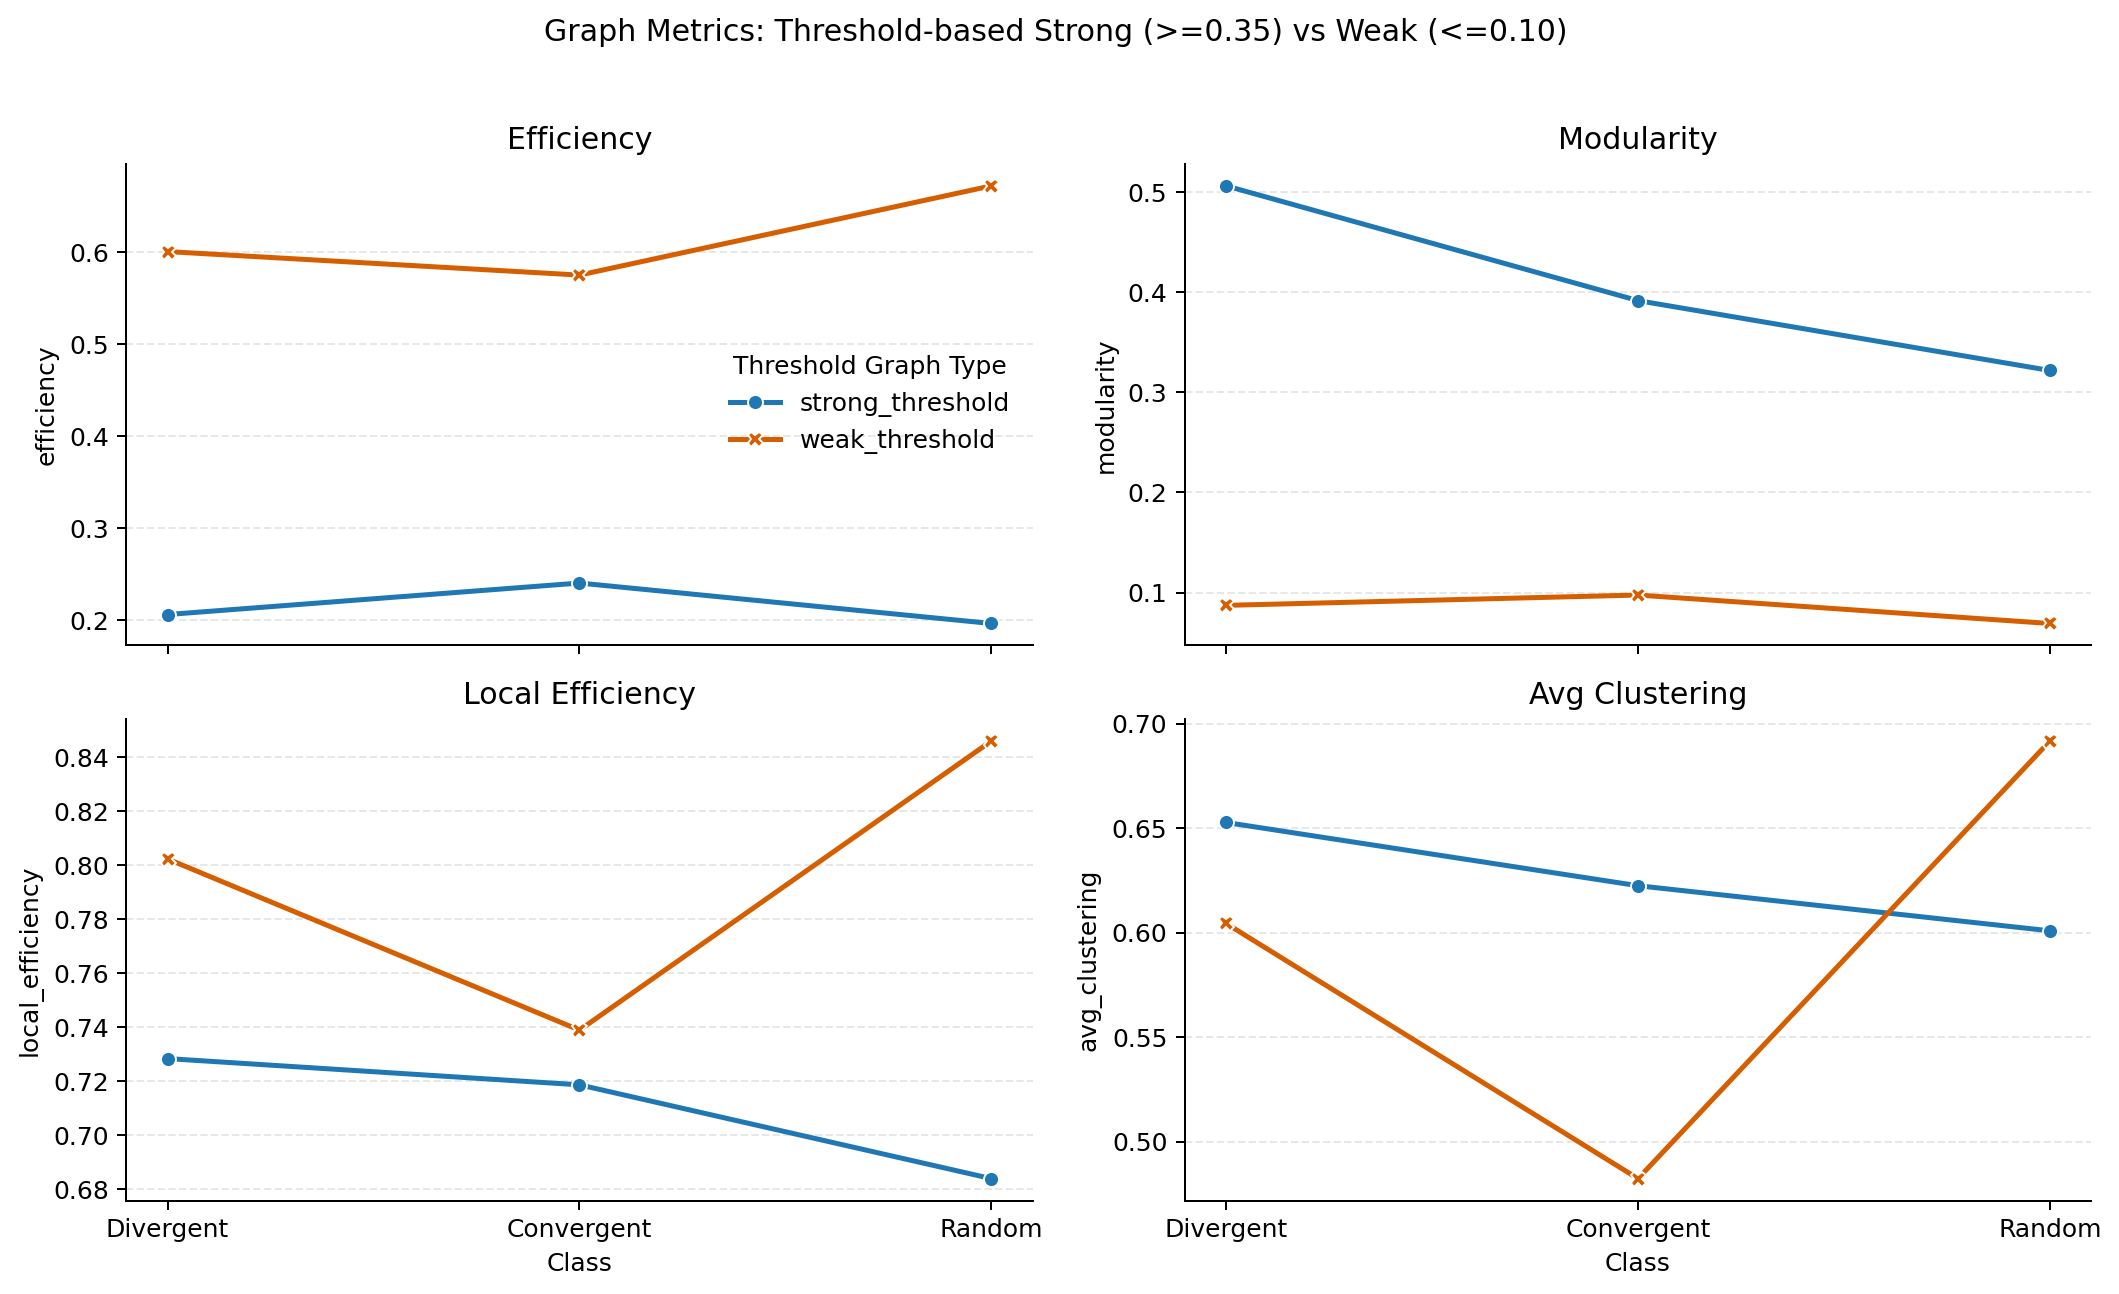

In [50]:

import networkx as nx
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

strong_threshold = 0.35
weak_threshold = 0.10


def build_threshold_graph_from_corr(corr_matrix, mode="strong", strong_thr=0.35, weak_thr=0.10, weighted=False):
    """Build graph using thresholded raw correlations."""
    corr = np.asarray(corr_matrix, dtype=float)
    n = corr.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))

    edge_vals = []
    for i in range(n):
        for j in range(i + 1, n):
            v = float(corr[i, j])
            if mode == "strong" and v >= strong_thr:
                edge_vals.append(v)
                if weighted:
                    G.add_edge(i, j, weight=v)
                else:
                    G.add_edge(i, j)
            elif mode == "weak" and v <= weak_thr:
                edge_vals.append(v)
                if weighted:
                    G.add_edge(i, j, weight=v)
                else:
                    G.add_edge(i, j)

    return G, np.asarray(edge_vals, dtype=float)


# Reuse metric helper if available; otherwise define a local one.
if 'compute_graph_metrics' not in globals():
    def compute_graph_metrics(G):
        if G.number_of_edges() == 0:
            return {
                'efficiency': 0.0,
                'modularity': 0.0,
                'local_efficiency': 0.0,
                'avg_clustering': 0.0,
                'density': 0.0,
                'n_edges': 0,
            }

        communities = list(nx.algorithms.community.greedy_modularity_communities(G))
        modularity = nx.algorithms.community.modularity(G, communities) if communities else 0.0

        return {
            'efficiency': float(nx.global_efficiency(G)),
            'modularity': float(modularity),
            'local_efficiency': float(nx.local_efficiency(G)) if G.number_of_nodes() > 1 else 0.0,
            'avg_clustering': float(nx.average_clustering(G)),
            'density': float(nx.density(G)),
            'n_edges': int(G.number_of_edges()),
        }


rows_thr = []
for cls in sorted(nx_result):
    corr_matrix = np.asarray(nx_result[cls]['corr_matrix'], dtype=float)
    class_name = label_names.get(cls, str(cls)) if 'label_names' in globals() else str(cls)

    for mode in ['strong', 'weak']:
        G_thr, edge_vals = build_threshold_graph_from_corr(
            corr_matrix,
            mode=mode,
            strong_thr=strong_threshold,
            weak_thr=weak_threshold,
            weighted=False,
        )
        metrics = compute_graph_metrics(G_thr)
        rows_thr.append({
            'Class_ID': cls,
            'Class_Name': class_name,
            'Network_Type': f'{mode}_threshold',
            'Strong_Threshold': strong_threshold,
            'Weak_Threshold': weak_threshold,
            'Edge_Mean_Corr': float(np.mean(edge_vals)) if edge_vals.size > 0 else np.nan,
            'Edge_Min_Corr': float(np.min(edge_vals)) if edge_vals.size > 0 else np.nan,
            'Edge_Max_Corr': float(np.max(edge_vals)) if edge_vals.size > 0 else np.nan,
            **metrics,
        })


df_topology_threshold = pd.DataFrame(rows_thr)

csv_path_thr = os.path.join(data_out_dir, 'network_metrics_threshold_strong0.35_weak0.10.csv')
df_topology_threshold.to_csv(csv_path_thr, index=False)
print(f'[*] Threshold-based graph metrics saved to: {csv_path_thr}')

# Plot threshold-based comparison
metrics_to_plot = ['efficiency', 'modularity', 'local_efficiency', 'avg_clustering']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=180, sharex=True)
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    sns.lineplot(
        data=df_topology_threshold,
        x='Class_Name',
        y=metric,
        hue='Network_Type',
        style='Network_Type',
        markers=True,
        dashes=False,
        linewidth=2,
        palette={'strong_threshold': '#1F77B4', 'weak_threshold': '#D55E00'},
        ax=ax,
    )
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Class')
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[1:]:
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, frameon=False, title='Threshold Graph Type')

fig.suptitle('Graph Metrics: Threshold-based Strong (>=0.35) vs Weak (<=0.10)', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, 'network_metrics_threshold_strong_vs_weak_line.png'), dpi=300, bbox_inches='tight')
plt.show()



<a id="sec-4"></a>
## 4. Trial Aggregation and Class Balancing

Aggregate activity in a key time window and balance class sample counts.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


In [52]:
# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:13], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)


<a id="sec-5"></a>
## 5. Neural Pattern Visualization

Show condition-related activity patterns by preference sorting and clustering.


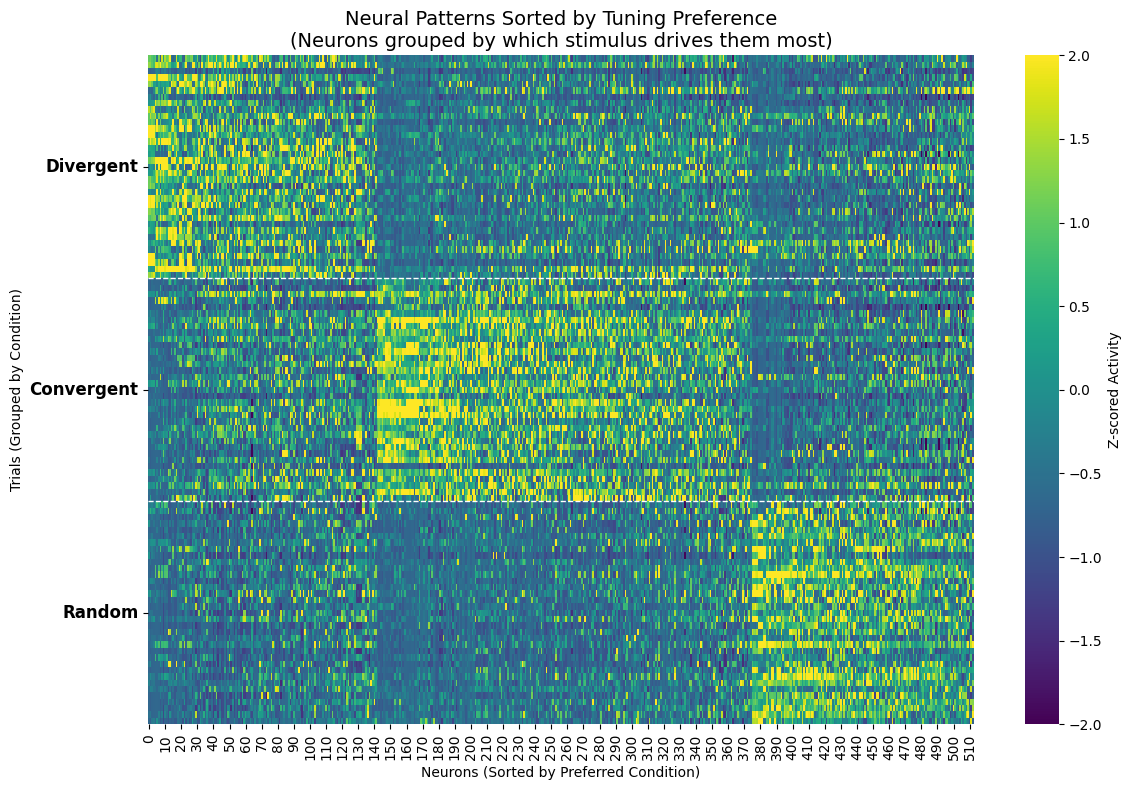

Generating Clustermap (Hierarchical Clustering)...


/beegfs_hdd/data/nfs_share/users/guiyun/nishome/brainnetwork/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


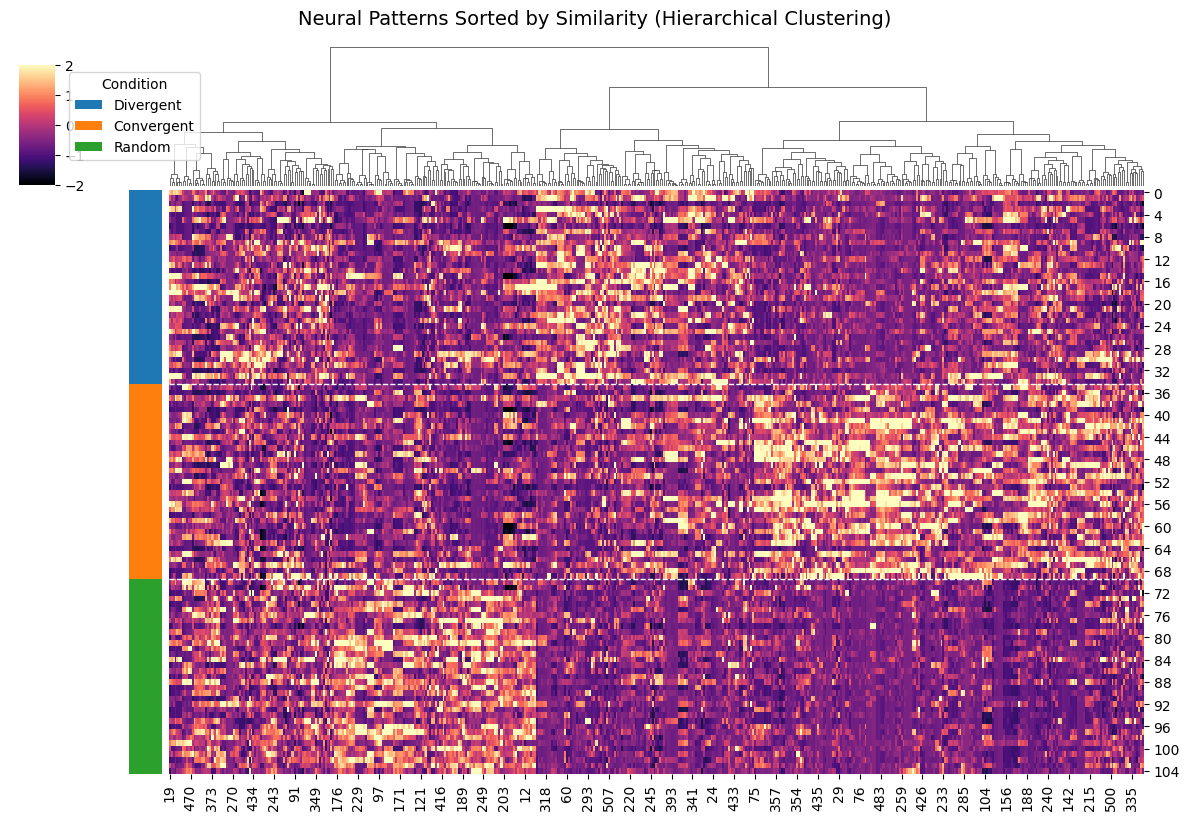

In [53]:
from scipy.stats import zscore

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random', 0: 'Resting'}

def plot_sorted_neural_patterns(X, labels, label_map):
    """
    可视化神经元活动热图，通过两种策略对神经元（X轴）进行排序，
    以揭示不同刺激条件（Y轴）下的Pattern差异。
    """
    
    # 1. 数据预处理
    # ------------------------------------------------
    # Z-score 归一化：消除神经元绝对发放率的差异，只看相对变化
    # axis=0 对每一列（神经元）做归一化
    X_norm = zscore(X, axis=0)
    
    # 替换 NaN (如果有些神经元完全不发放，std为0，zscore会产生nan)
    X_norm = np.nan_to_num(X_norm)
    
    unique_labels = np.unique(labels)
    sorted_labels = sorted(unique_labels) # 确保顺序: Divergent, Convergent, Random...
    
    # 获取标签的分界线位置，用于画横线
    label_counts = [np.sum(labels == l) for l in sorted_labels]
    boundaries = np.cumsum(label_counts)[:-1]
    
    # 重新排列 X 的行（Trial），确保它是按 Label 顺序排列的
    # (虽然通常已经是排好的，但为了保险起见)
    trial_sort_idx = np.argsort(labels)
    X_sorted_trials = X_norm[trial_sort_idx]
    labels_sorted = labels[trial_sort_idx]
    
    # ------------------------------------------------
    # 策略一：偏好性排序 (Preference Sorting)
    # ------------------------------------------------
    # 计算每个神经元在各条件下的平均活动
    n_neurons = X.shape[1]
    neuron_means = np.zeros((len(unique_labels), n_neurons))
    
    for i, l in enumerate(sorted_labels):
        # 找到该条件下的所有行
        mask = (labels == l)
        # 计算该条件下每个神经元的均值
        neuron_means[i, :] = np.mean(X_norm[mask], axis=0)
        
    # 找出每个神经元在哪个条件下最强 (Argmax)
    peak_condition_idx = np.argmax(neuron_means, axis=0)
    
    # 在同一个条件下，再按强度排个序，为了视觉更好看
    peak_magnitude = np.max(neuron_means, axis=0)
    
    # 综合排序键值: 先按条件ID排，再按强度排
    # 技巧: use lexsort. Primary key is last argument.
    sort_key = np.lexsort((-peak_magnitude, peak_condition_idx))
    
    X_pref_sorted = X_sorted_trials[:, sort_key]
    
    # ------------------------------------------------
    # 绘图 1: 偏好性排序热图
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(X_pref_sorted, ax=ax, cmap='viridis', vmin=-2, vmax=2, cbar_kws={'label': 'Z-scored Activity'})
    
    # 画水平线分隔不同条件
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    # 标注 Y 轴
    # 计算每个 Block 的中心位置
    y_centers = []
    current = 0
    for count in label_counts:
        y_centers.append(current + count/2)
        current += count
        
    ax.set_yticks(y_centers)
    ax.set_yticklabels([label_map[l] for l in sorted_labels], rotation=0, fontsize=12, fontweight='bold')
    
    ax.set_title("Neural Patterns Sorted by Tuning Preference\n(Neurons grouped by which stimulus drives them most)", fontsize=14)
    ax.set_xlabel("Neurons (Sorted by Preferred Condition)")
    ax.set_ylabel("Trials (Grouped by Condition)")
    
    plt.tight_layout()
    save_path = os.path.join(fig_out_dir, "neural_patterns_preference_sorted.png")
    fig.savefig(save_path, dpi=300)
    plt.show()

    # ------------------------------------------------
    # 策略二：层次聚类 (Hierarchical Clustering)
    # ------------------------------------------------
    # 这会展示神经元的自然功能团
    print("Generating Clustermap (Hierarchical Clustering)...")
    
    # 创建行颜色条
    label_colors = {l: sns.color_palette("tab10")[i] for i, l in enumerate(unique_labels)}
    row_colors = [label_colors[l] for l in labels_sorted]
    
    g = sns.clustermap(X_sorted_trials, 
                       method='ward', # 聚类算法
                       metric='euclidean',
                       col_cluster=True, # 对神经元聚类
                       row_cluster=False, # 不对 Trial 聚类 (保持条件顺序)
                       row_colors=row_colors,
                       cmap='magma', vmin=-2, vmax=2,
                       figsize=(12, 8),
                       dendrogram_ratio=(0.1, 0.2),
                       cbar_pos=(0.02, 0.8, 0.03, 0.15))
    
    # 添加水平线
    for b in boundaries:
        g.ax_heatmap.hlines(b, *g.ax_heatmap.get_xlim(), colors='white', linestyles='--', linewidth=1)
        
    g.fig.suptitle("Neural Patterns Sorted by Similarity (Hierarchical Clustering)", y=1.02, fontsize=14)
    
    # 手动添加 Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=label_colors[l], label=label_map[l]) for l in sorted_labels]
    plt.legend(handles=handles, title='Condition', bbox_to_anchor=(1.2, 1), loc='upper left')
    save_path = os.path.join(fig_out_dir, "neural_patterns_clustermap.png")
    g.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 运行代码
# 确保 X_trial_averaged_balanced 是 (n_trials, n_neurons)
plot_sorted_neural_patterns(X_trial_averaged_balanced, labels_balanced, label_names)

<a id="sec-6"></a>
## 6. RSM and Entropy

Compute trial-level similarity distributions and Shannon entropy.


Stimulus        | Entropy (Bits)  | Mean Similarity | Std Similarity 
----------------------------------------------------------------------
Divergent       | 3.6511           | 0.5413          | 0.1245
Convergent      | 3.5419           | 0.5601          | 0.1206
Random          | 3.4855           | 0.6647          | 0.1152


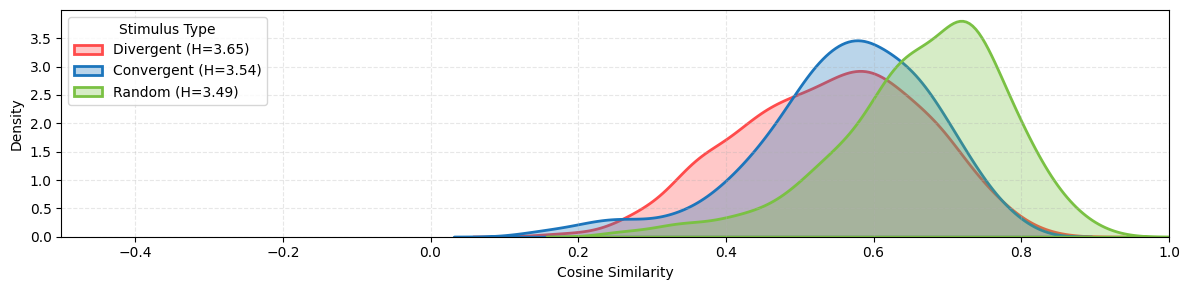

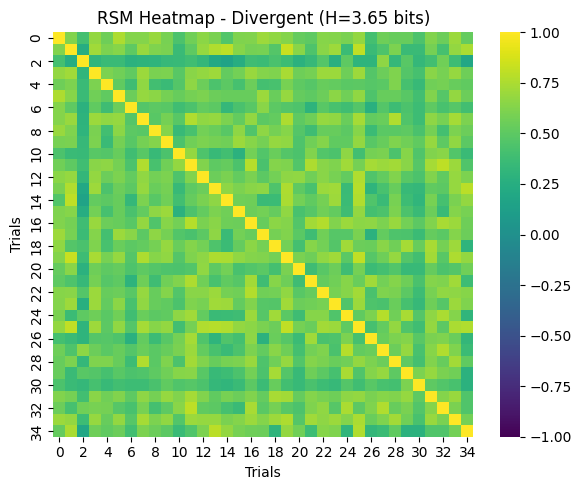

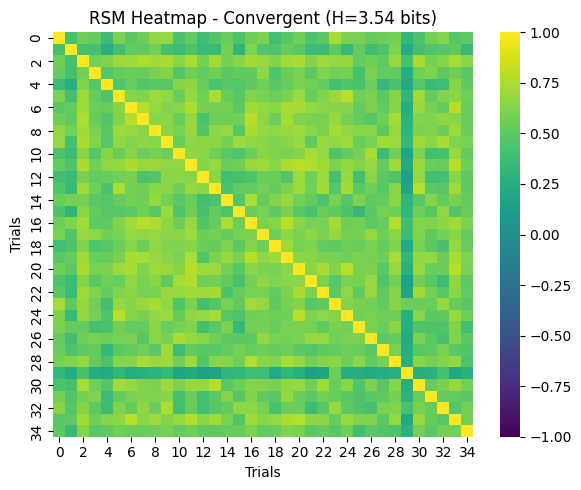

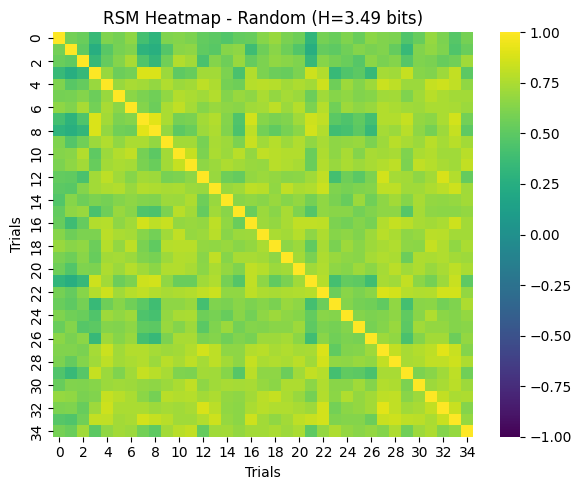

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

def analyze_rsm_and_entropy(X, labels, label_map, n_bins=50):
    """
    计算不同刺激条件下的RSM熵值和相似度分布
    """
    results = []
    rsm_dict = {}
    similarity_values_dict = {}

    print(f"{'Stimulus':<15} | {'Entropy (Bits)':<15} | {'Mean Similarity':<15} | {'Std Similarity':<15}")
    print("-" * 70)

    # 遍历每种刺激标签
    unique_labels = np.unique(labels)
    for label in unique_labels:
        name = label_map[label]
        
        # 1. 提取该条件下的数据
        mask = (labels == label)
        X_sub = X[mask]
        
        # 2. 计算 RSM (Cosine Similarity)
        # 结果是 (n_trials, n_trials) 的矩阵，范围 [-1, 1]
        rsm = cosine_similarity(X_sub)
        rsm_dict[name] = rsm
        
        # 3. 提取上三角非对角线元素 (Off-diagonal upper triangle)
        # k=1 表示不包含对角线。因为我们只关心试次间的变异，不关心试次和自己的相似度
        triu_indices = np.triu_indices_from(rsm, k=1)
        sim_values = rsm[triu_indices]
        similarity_values_dict[name] = sim_values
        
        # 4. 计算香农熵 (Shannon Entropy)
        # 先将连续的相似度值通过直方图转为概率分布
        # range=(-1, 1) 覆盖余弦相似度的理论范围
        counts, _ = np.histogram(sim_values, bins=n_bins, range=(-1, 1), density=True)
        
        # 归一化为概率 (加上极小值防止 log(0) 错误)
        probs = counts / np.sum(counts)
        ent = entropy(probs, base=2)  # base=2 单位为 bits
        
        # 记录统计量
        results.append({
            'Stimulus': name,
            'Entropy': ent,
            'Mean_Sim': np.mean(sim_values),
            'Std_Sim': np.std(sim_values)
        })
        
        print(f"{name:<15} | {ent:.4f}           | {np.mean(sim_values):.4f}          | {np.std(sim_values):.4f}")

    return pd.DataFrame(results), rsm_dict, similarity_values_dict


df_entropy, rsm_data, sim_values_data = analyze_rsm_and_entropy(
    X_trial_averaged_balanced, 
    labels_balanced, 
    label_names,
    n_bins=50 # 分箱数，可以根据数据量调整，通常 30-100 之间
)

# --- 可视化 1: 相似度分布直方图 (验证是否"变平"了) ---
plt.figure(figsize=(12, 3))
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': '#111111'}

for name, values in sim_values_data.items():
    sns.kdeplot(values, label=f"{name} (H={df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.2f})", 
                color=colors[name], fill=True, alpha=0.3, linewidth=2)

# plt.title("Distribution of Pairwise Cosine Similarities (RSM Off-diagonal)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.xlim(-0.5, 1.0) # 根据实际数据范围调整
plt.legend(title="Stimulus Type")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save_path = os.path.join(fig_out_dir, "similarity_distribution.png")
plt.savefig(save_path, dpi=300)
plt.show()

# plot heatmap of RSM
for name, rsm in rsm_data.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(rsm, cmap='viridis', vmin=-1, vmax=1) #cbar_kws={'label': 'Cosine Similarity'})
    # 不要颜色条了，直接在标题里写熵值
    

    plt.title(f"RSM Heatmap - {name} (H={df_entropy[df_entropy['Stimulus']==name]['Entropy'].values[0]:.2f} bits)")
    plt.xlabel("Trials")
    plt.ylabel("Trials")
    plt.tight_layout()
    save_path = os.path.join(fig_out_dir, f"rsm_heatmap_{name}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

## 6.1 Response Sparsity and Effective Dimensionality

Compute trial-level Gini and Participation Ratio, plus class-level covariance-spectrum effective dimensionality.


[*] Trial-level response shape metrics saved: ../results/M73_1128/data/trial_response_shape_metrics.csv
[*] Trial-level summary saved: ../results/M73_1128/data/trial_response_shape_summary.csv
[*] Effective dimensionality saved: ../results/M73_1128/data/effective_dimensionality_by_class.csv


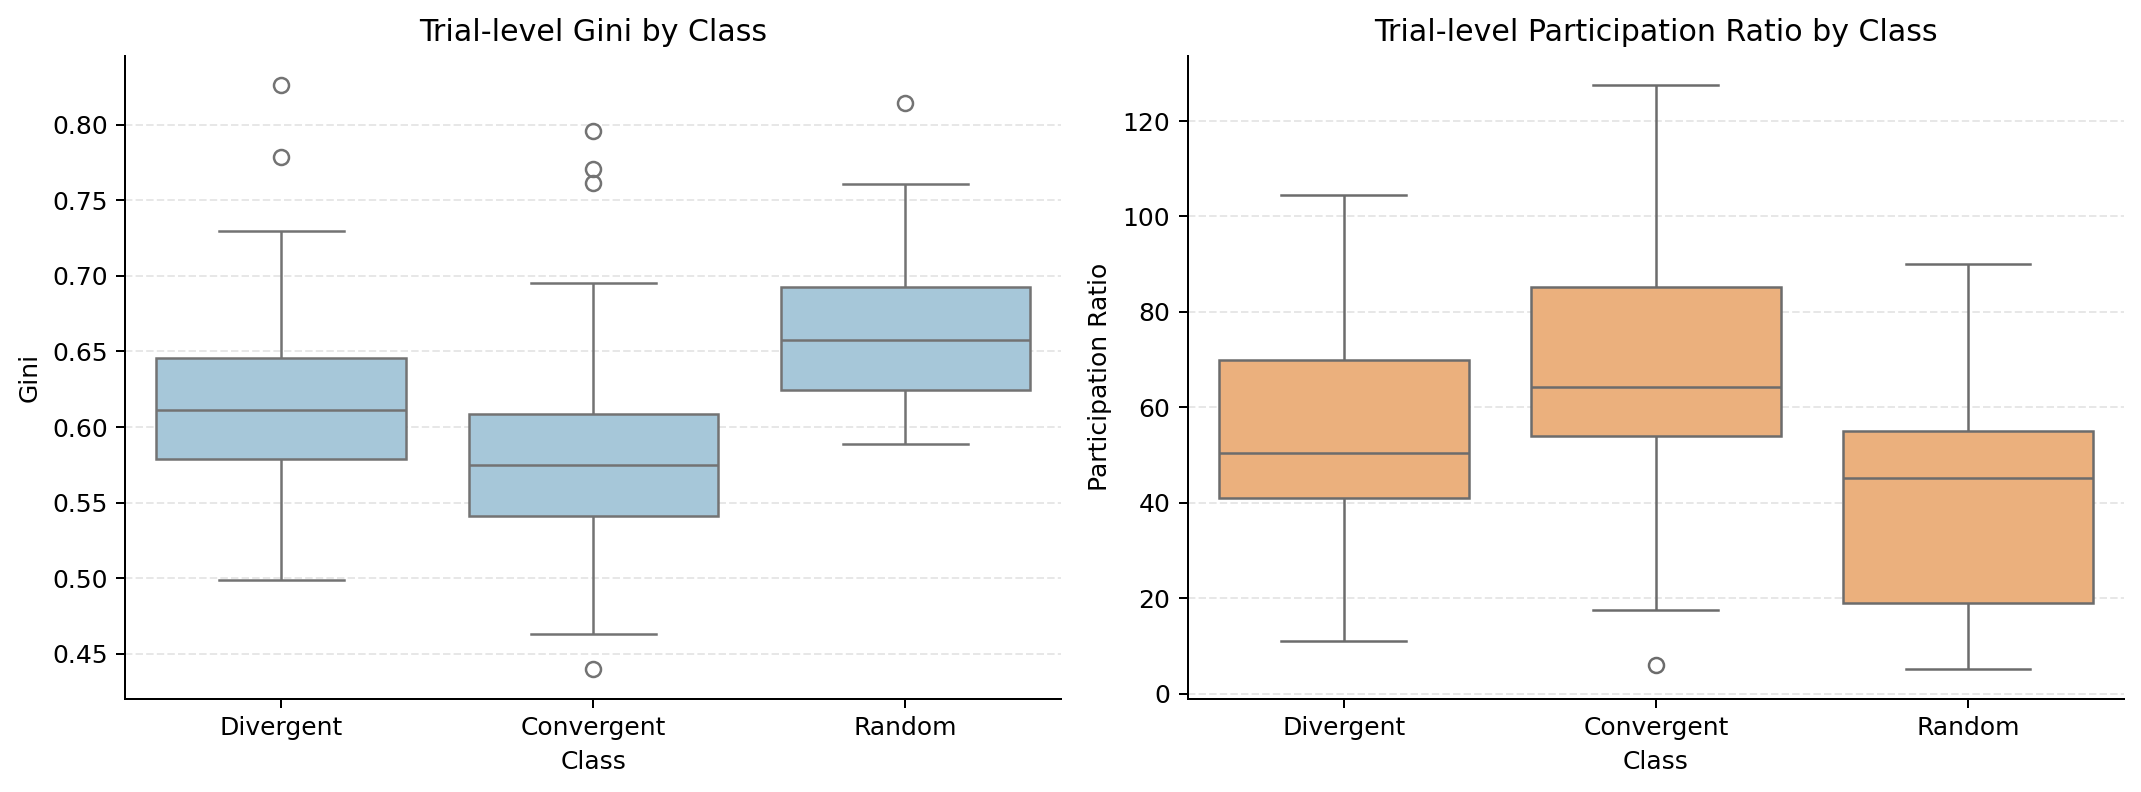

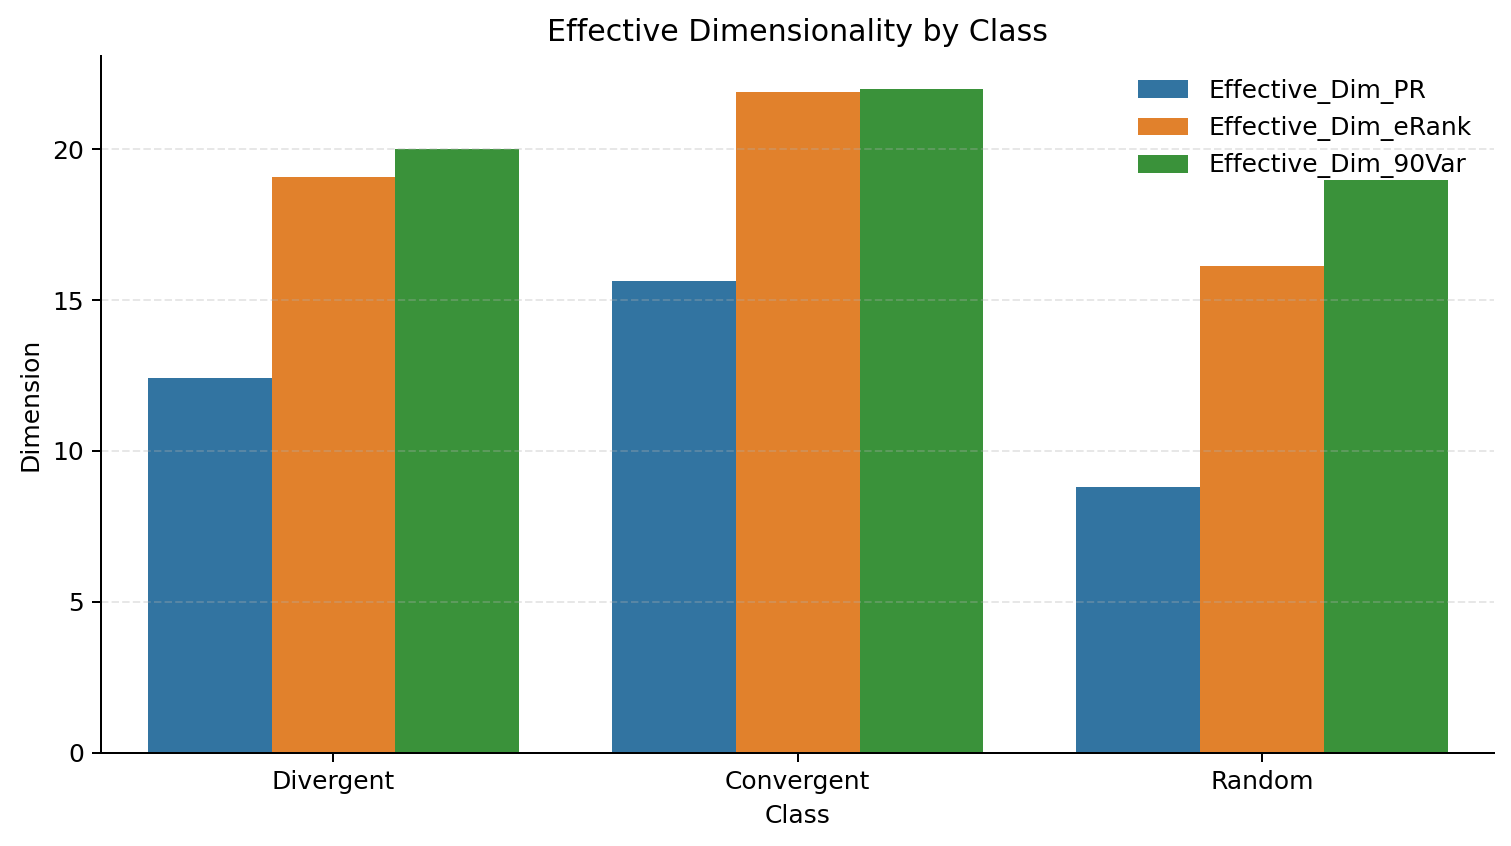

In [55]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def gini_coefficient(x):
    """Gini coefficient for a 1D response vector."""
    x = np.asarray(x, dtype=float).ravel()
    if x.size == 0:
        return np.nan

    # Shift to non-negative if needed (keeps inequality structure)
    min_x = np.min(x)
    if min_x < 0:
        x = x - min_x

    s = np.sum(x)
    if s <= 1e-12:
        return 0.0

    x_sorted = np.sort(x)
    n = x_sorted.size
    idx = np.arange(1, n + 1)
    g = (2.0 * np.sum(idx * x_sorted) / (n * s)) - (n + 1) / n
    return float(g)


def participation_ratio_vector(x):
    """Participation ratio of one trial response vector."""
    x = np.asarray(x, dtype=float).ravel()
    num = np.sum(x ** 2) ** 2
    den = np.sum(x ** 4)
    if den <= 1e-12:
        return 0.0
    return float(num / den)


def effective_dims_from_cov(X):
    """Return PR-dimension and entropy-rank dimension from covariance eigen-spectrum."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[0] < 2:
        return np.nan, np.nan, np.nan

    Xc = X - np.mean(X, axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = eigvals[eigvals > 1e-12]
    if eigvals.size == 0:
        return 0.0, 0.0, 0.0

    # PR dimension
    pr_dim = (np.sum(eigvals) ** 2) / np.sum(eigvals ** 2)

    # Entropy-rank (effective rank)
    p = eigvals / np.sum(eigvals)
    erank_dim = np.exp(-np.sum(p * np.log(p + 1e-12)))

    # 90% variance dimension
    eig_sorted = np.sort(eigvals)[::-1]
    cumsum = np.cumsum(eig_sorted) / np.sum(eig_sorted)
    dim90 = int(np.searchsorted(cumsum, 0.90) + 1)

    return float(pr_dim), float(erank_dim), float(dim90)


# Use balanced trial-level matrix computed above: shape (n_trials, n_neurons)
X_resp = np.asarray(X_trial_averaged_balanced, dtype=float)
y_resp = np.asarray(labels_balanced)

trial_rows = []
for i in range(X_resp.shape[0]):
    cls = int(y_resp[i])
    v = X_resp[i]
    trial_rows.append({
        "Trial_Index": i,
        "Class_ID": cls,
        "Class_Name": label_names.get(cls, str(cls)) if "label_names" in globals() else str(cls),
        "Gini": gini_coefficient(v),
        "Participation_Ratio": participation_ratio_vector(v),
        "Participation_Ratio_Norm": participation_ratio_vector(v) / max(1, v.size),
    })

df_trial_shape = pd.DataFrame(trial_rows)

# Class-level effective dimensionality from covariance spectrum
dim_rows = []
for cls in sorted(np.unique(y_resp)):
    X_cls = X_resp[y_resp == cls]
    pr_dim, erank_dim, dim90 = effective_dims_from_cov(X_cls)
    dim_rows.append({
        "Class_ID": int(cls),
        "Class_Name": label_names.get(int(cls), str(int(cls))) if "label_names" in globals() else str(int(cls)),
        "N_Trials": int(X_cls.shape[0]),
        "N_Neurons": int(X_cls.shape[1]),
        "Effective_Dim_PR": pr_dim,
        "Effective_Dim_eRank": erank_dim,
        "Effective_Dim_90Var": dim90,
    })

df_effective_dim = pd.DataFrame(dim_rows)

# Summary stats for trial-level metrics
agg = {
    "Gini": ["mean", "std"],
    "Participation_Ratio": ["mean", "std"],
    "Participation_Ratio_Norm": ["mean", "std"],
}
df_trial_shape_summary = df_trial_shape.groupby(["Class_ID", "Class_Name"]).agg(agg).reset_index()
df_trial_shape_summary.columns = [
    "Class_ID", "Class_Name",
    "Gini_Mean", "Gini_STD",
    "PR_Mean", "PR_STD",
    "PR_Norm_Mean", "PR_Norm_STD",
]

# Save tables
trial_csv = os.path.join(data_out_dir, "trial_response_shape_metrics.csv")
trial_summary_csv = os.path.join(data_out_dir, "trial_response_shape_summary.csv")
dim_csv = os.path.join(data_out_dir, "effective_dimensionality_by_class.csv")

df_trial_shape.to_csv(trial_csv, index=False)
df_trial_shape_summary.to_csv(trial_summary_csv, index=False)
df_effective_dim.to_csv(dim_csv, index=False)

print(f"[*] Trial-level response shape metrics saved: {trial_csv}")
print(f"[*] Trial-level summary saved: {trial_summary_csv}")
print(f"[*] Effective dimensionality saved: {dim_csv}")

# Plot A: Trial-level Gini / PR by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=180)

sns.boxplot(data=df_trial_shape, x="Class_Name", y="Gini", ax=axes[0], color="#9ecae1")
axes[0].set_title("Trial-level Gini by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Gini")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sns.boxplot(data=df_trial_shape, x="Class_Name", y="Participation_Ratio", ax=axes[1], color="#fdae6b")
axes[1].set_title("Trial-level Participation Ratio by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Participation Ratio")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, "response_gini_pr_by_class.png"), dpi=300, bbox_inches="tight")
plt.show()

# Plot B: Effective dimensionality comparison
df_dim_long = df_effective_dim.melt(
    id_vars=["Class_ID", "Class_Name"],
    value_vars=["Effective_Dim_PR", "Effective_Dim_eRank", "Effective_Dim_90Var"],
    var_name="Metric",
    value_name="Value",
)

fig2, ax2 = plt.subplots(figsize=(8.5, 4.8), dpi=180)
sns.barplot(data=df_dim_long, x="Class_Name", y="Value", hue="Metric", ax=ax2)
ax2.set_title("Effective Dimensionality by Class")
ax2.set_xlabel("Class")
ax2.set_ylabel("Dimension")
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False)
fig2.tight_layout()
fig2.savefig(os.path.join(fig_out_dir, "effective_dimensionality_by_class.png"), dpi=300, bbox_inches="tight")
plt.show()



<a id="sec-7"></a>
## 7. Class-wise RR Selection

Extract reliable-response neuron sets for each stimulus class.


In [56]:
# Experiment configuration
rr_neurons_spi = rr_selection_class(segments_spi, labels_spi)


使用快速RR筛选算法 (按类分别筛选取并集)...
  - 类别 1 贡献了 218 个 RR 神经元
  - 类别 2 贡献了 312 个 RR 神经元
  - 类别 3 贡献了 170 个 RR 神经元


In [57]:
rr_neurons_spi.keys()
rr_union = set.union(*rr_neurons_spi.values())
# rr_union

## 7.1 RR Set Export and Venn Visualization

Save class-wise RR neuron sets and overlap statistics, then visualize overlap with a Venn diagram.


[*] RR set JSON saved to: ../results/M73_1128/data/rr_sets_by_class.json
[*] RR overlap summary CSV saved to: ../results/M73_1128/data/rr_overlap_summary.csv
[*] RR membership CSV saved to: ../results/M73_1128/data/rr_neuron_membership.csv


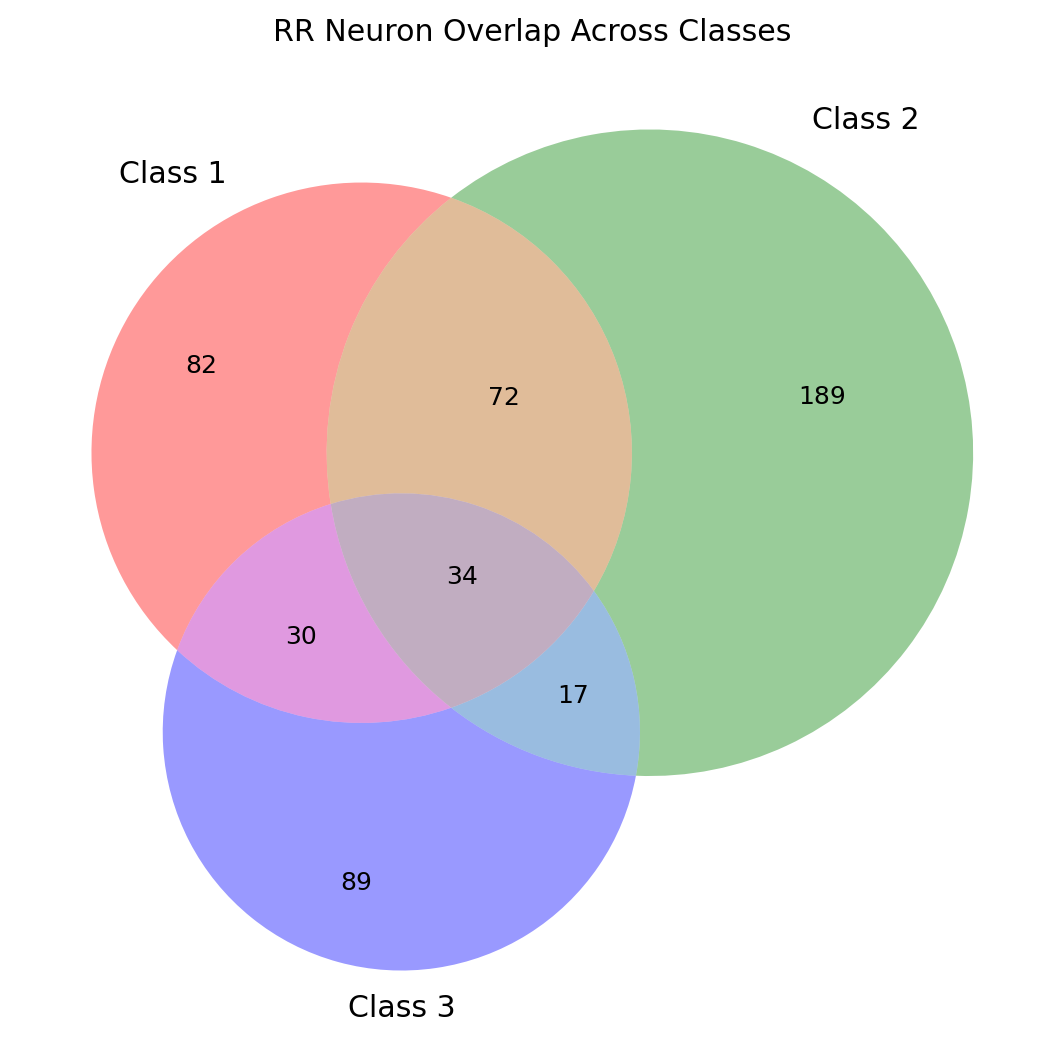

[*] RR Venn figure saved to: ../results/M73_1128/figures/rr_sets_venn.png


In [58]:

import os
import json
import itertools
import pandas as pd
import matplotlib.pyplot as plt

# Normalize class-wise RR sets
rr_sets = {int(cls): set(map(int, neurons)) for cls, neurons in rr_neurons_spi.items()}
class_ids = sorted(rr_sets.keys())

if len(class_ids) == 0:
    raise ValueError("rr_neurons_spi is empty; cannot export RR set information.")

# Basic counts
rr_union = set.union(*rr_sets.values()) if rr_sets else set()
rr_intersection_all = set.intersection(*rr_sets.values()) if rr_sets else set()

# Build overlap summary rows
overlap_rows = []
for cls in class_ids:
    overlap_rows.append({
        "Subset": f"Class_{cls}",
        "Subset_Size": len(rr_sets[cls]),
    })

for a, b in itertools.combinations(class_ids, 2):
    overlap_rows.append({
        "Subset": f"Class_{a}&Class_{b}",
        "Subset_Size": len(rr_sets[a] & rr_sets[b]),
    })

if len(class_ids) >= 3:
    overlap_rows.append({
        "Subset": "All_Classes_Intersection",
        "Subset_Size": len(rr_intersection_all),
    })

overlap_rows.append({"Subset": "Union_All", "Subset_Size": len(rr_union)})

df_rr_overlap = pd.DataFrame(overlap_rows)

# Build neuron membership table for downstream stats
membership_rows = []
for nid in sorted(rr_union):
    row = {"Neuron_ID": int(nid)}
    active = []
    for cls in class_ids:
        in_set = int(nid in rr_sets[cls])
        row[f"Class_{cls}"] = in_set
        if in_set:
            active.append(str(cls))
    row["Membership_Pattern"] = ",".join(active)
    row["Membership_Count"] = len(active)
    membership_rows.append(row)

df_rr_membership = pd.DataFrame(membership_rows)

# Save structured RR-set data
rr_set_json_path = os.path.join(data_out_dir, "rr_sets_by_class.json")
rr_overlap_csv_path = os.path.join(data_out_dir, "rr_overlap_summary.csv")
rr_membership_csv_path = os.path.join(data_out_dir, "rr_neuron_membership.csv")

rr_json = {
    "class_ids": class_ids,
    "rr_sets": {str(cls): sorted(list(rr_sets[cls])) for cls in class_ids},
    "union_all": sorted(list(rr_union)),
    "intersection_all": sorted(list(rr_intersection_all)),
}

with open(rr_set_json_path, "w", encoding="utf-8") as f:
    json.dump(rr_json, f, indent=2)

df_rr_overlap.to_csv(rr_overlap_csv_path, index=False)
df_rr_membership.to_csv(rr_membership_csv_path, index=False)

print(f"[*] RR set JSON saved to: {rr_set_json_path}")
print(f"[*] RR overlap summary CSV saved to: {rr_overlap_csv_path}")
print(f"[*] RR membership CSV saved to: {rr_membership_csv_path}")

# Plot venn diagram for exactly 3 classes if available
if len(class_ids) == 3:
    try:
        from matplotlib_venn import venn3

        a, b, c = class_ids
        set_a, set_b, set_c = rr_sets[a], rr_sets[b], rr_sets[c]

        fig, ax = plt.subplots(figsize=(6.8, 6), dpi=180)
        venn3(
            subsets=(set_a, set_b, set_c),
            set_labels=(f"Class {a}", f"Class {b}", f"Class {c}"),
            ax=ax,
        )
        ax.set_title("RR Neuron Overlap Across Classes")
        plt.tight_layout()

        venn_path = os.path.join(fig_out_dir, "rr_sets_venn.png")
        fig.savefig(venn_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"[*] RR Venn figure saved to: {venn_path}")
    except ImportError:
        print("[!] matplotlib-venn is not installed; skipped Venn plot. Install via: pip install matplotlib-venn")
else:
    print(f"[!] Venn plot skipped: expected exactly 3 classes, got {len(class_ids)} classes ({class_ids}).")



<a id="sec-8"></a>
## 8. Class-RR vs Other-RR

Compare condition-specific RR neurons with other RR neurons in the RR pool.


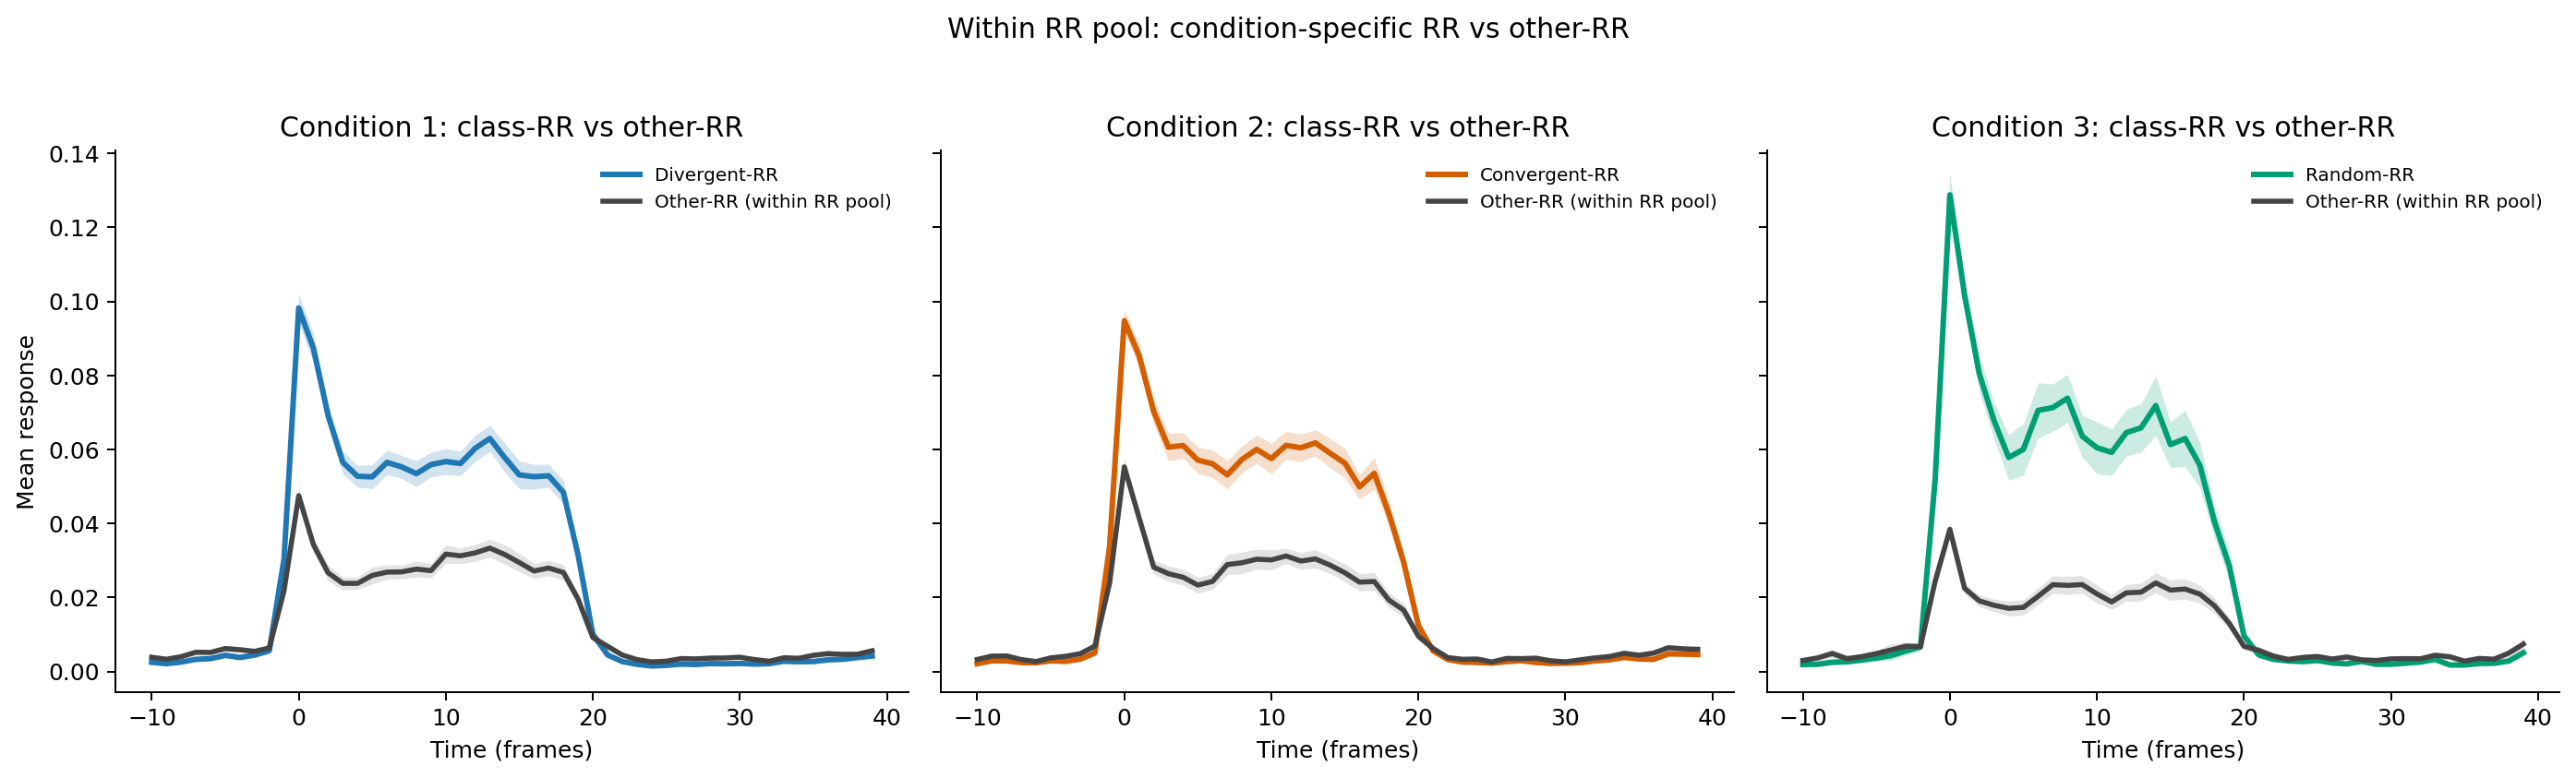

Participants (mean RR response at peak time / mean other-RR response at peak time):
Condition 1: 2.35
Condition 2: 2.00
Condition 3: 3.89


In [59]:
# Compare class-specific RR neurons with the remaining RR neurons inside the RR pool.
# This cell reuses rr_by_class / rr_union cached above and avoids recomputing RR sets.


# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}

class_colors = {1: '#1F77B4', 2: '#D55E00', 3: '#009E73'}

participants = {}

def class_curve_and_sem(segments_group, labels, cls):
    cls_segments = segments_group[labels == cls]
    pop_mean = np.nanmean(cls_segments, axis=(0, 1))
    trial_means = np.nanmean(cls_segments, axis=1)
    pop_sem = stats.sem(trial_means, axis=0, nan_policy="omit")
    return pop_mean, pop_sem

def pop_curve_and_sem(trials_subset):
    # trials_subset: (n_trials, n_neurons_subset, n_time)
    m = np.nanmean(trials_subset, axis=(0, 1))
    trial_means = np.nanmean(trials_subset, axis=1)  # (n_trials, n_time)
    se = stats.sem(trial_means, axis=0, nan_policy='omit')
    return m, se


time_axis = np.arange(-10,40) # Assuming segments_spi has 50 frames from -10 to +39
fig, axes = plt.subplots(1, len(label_names), figsize=(5.2 * len(label_names), 4.5), dpi=180, sharey=True)
if len(label_names) == 1:
    axes = [axes]
    
for ax, cls in zip(axes, label_names.keys()):
    cls_trials = segments_spi[labels_spi == cls]
    rr_cls = rr_neurons_spi[cls]
    other_rr = rr_union - set(rr_cls)

    if len(rr_cls) == 0:
        ax.set_title(f'Class {cls}: no class-specific RR')
        ax.axis('off')
        continue

    m_rr, se_rr = pop_curve_and_sem(cls_trials[:, list(rr_cls), :])
    ax.plot(time_axis, m_rr, color=class_colors.get(cls, '#1F77B4'), lw=2.4, label=f'{label_names.get(cls, cls)}-RR')
    ax.fill_between(time_axis, m_rr - se_rr, m_rr + se_rr, color=class_colors.get(cls, '#1F77B4'), alpha=0.2, linewidth=0)

    if len(other_rr)     > 0:
        m_oth, se_oth = pop_curve_and_sem(cls_trials[:, list(other_rr), :])
        ax.plot(time_axis, m_oth, color='#444444', lw=2.2, label='Other-RR (within RR pool)')
        ax.fill_between(time_axis, m_oth - se_oth, m_oth + se_oth, color='#444444', alpha=0.15, linewidth=0)

    try:
        participants[cls] = np.mean(m_rr[10:13])/ np.mean(m_oth[10:13]) if len(other_rr) > 0 else np.mean(m_rr[10:13])
    except ZeroDivisionError:
        participants[cls] = 0
    ax.set_title(f'Condition {cls}: class-RR vs other-RR')
    ax.set_xlabel('Time (frames)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel('Mean response')
fig.suptitle('Within RR pool: condition-specific RR vs other-RR', y=1.03)
fig.tight_layout()
plt.show()

print("Participants (mean RR response at peak time / mean other-RR response at peak time):")
for cls, value in participants.items():
    print(f"Condition {cls}: {value:.2f}")

<a id="sec-9"></a>
## 9. Strong vs Weak Connectivity

Quantify weak/strong correlation tails and their gap by class.


[*] Decile-level correlation stats saved to: ../results/M73_1128/data/correlation_deciles.csv


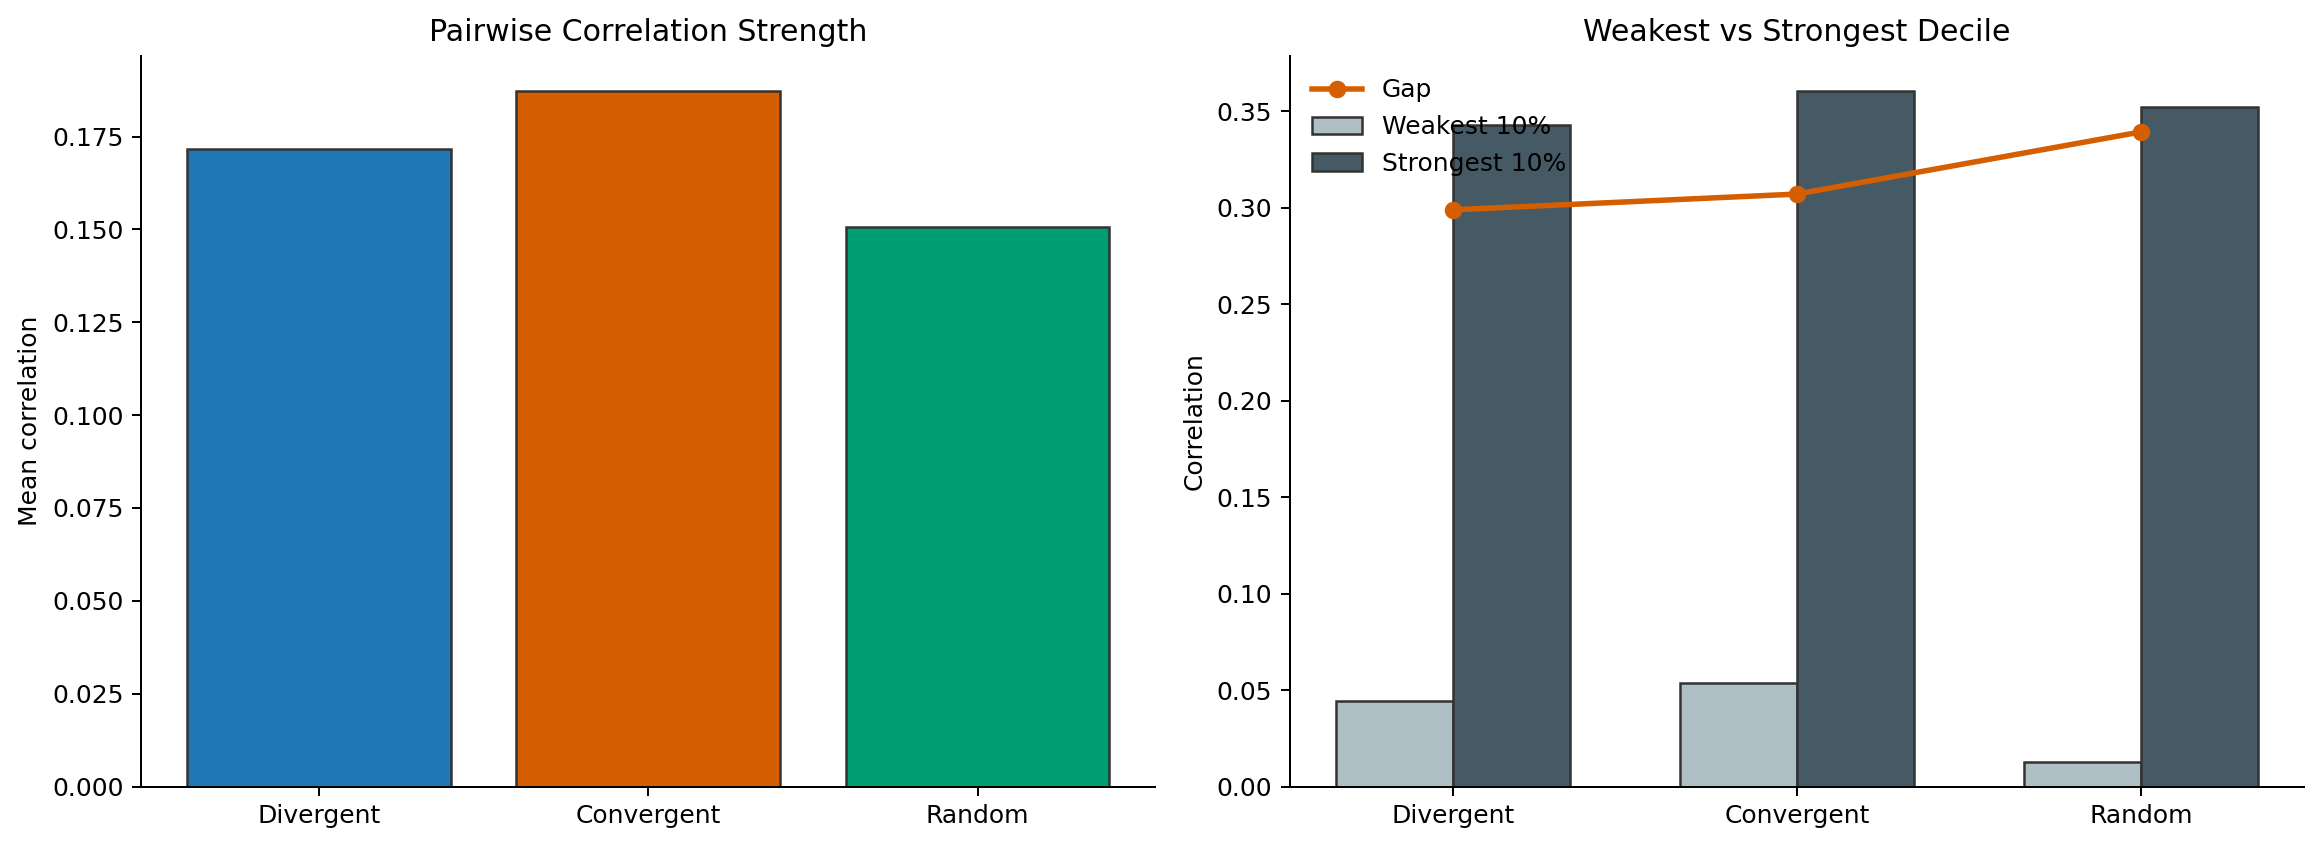

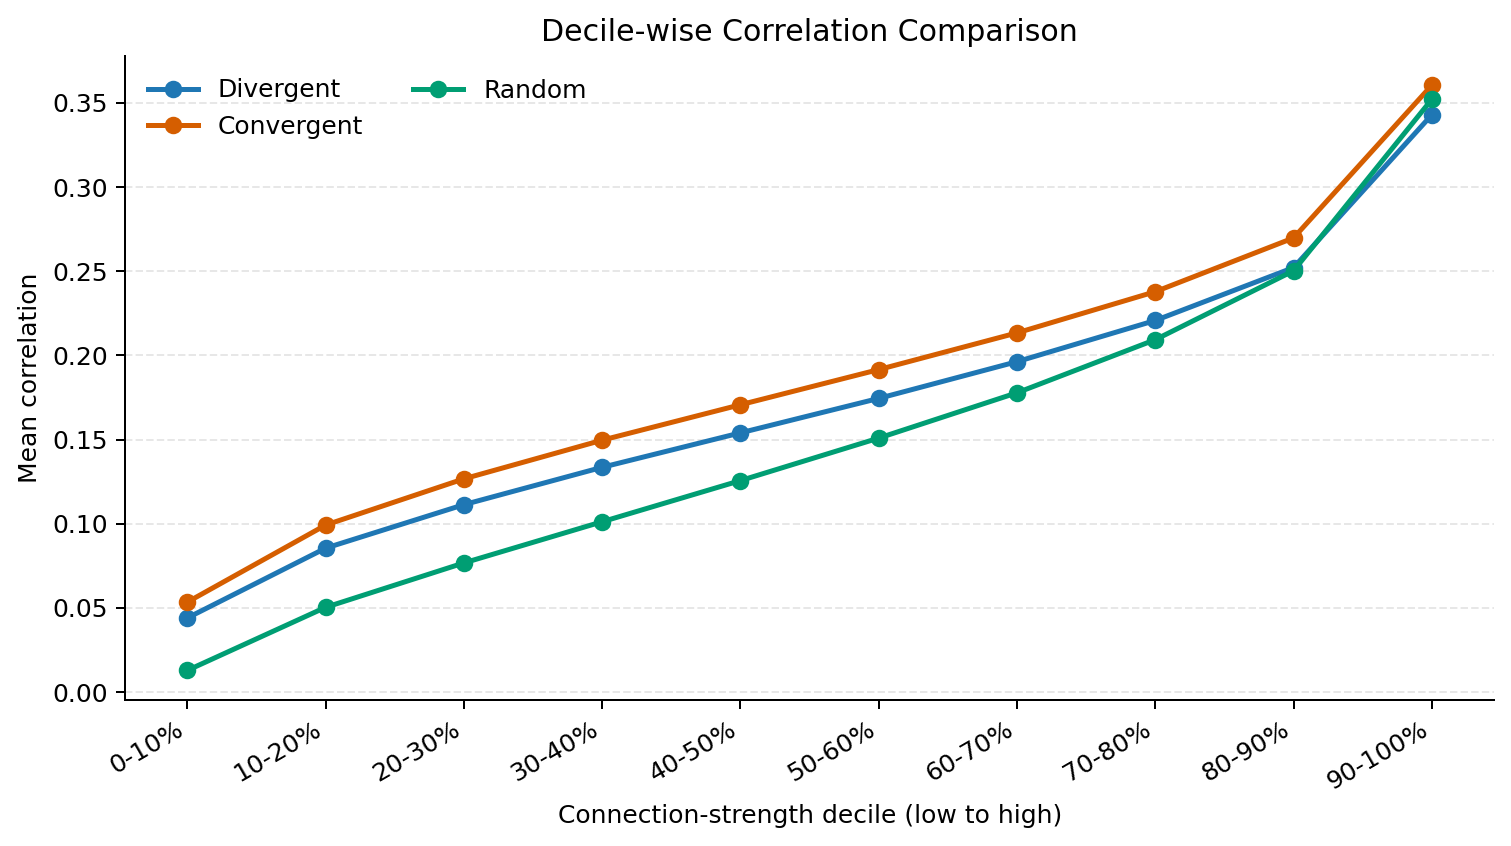

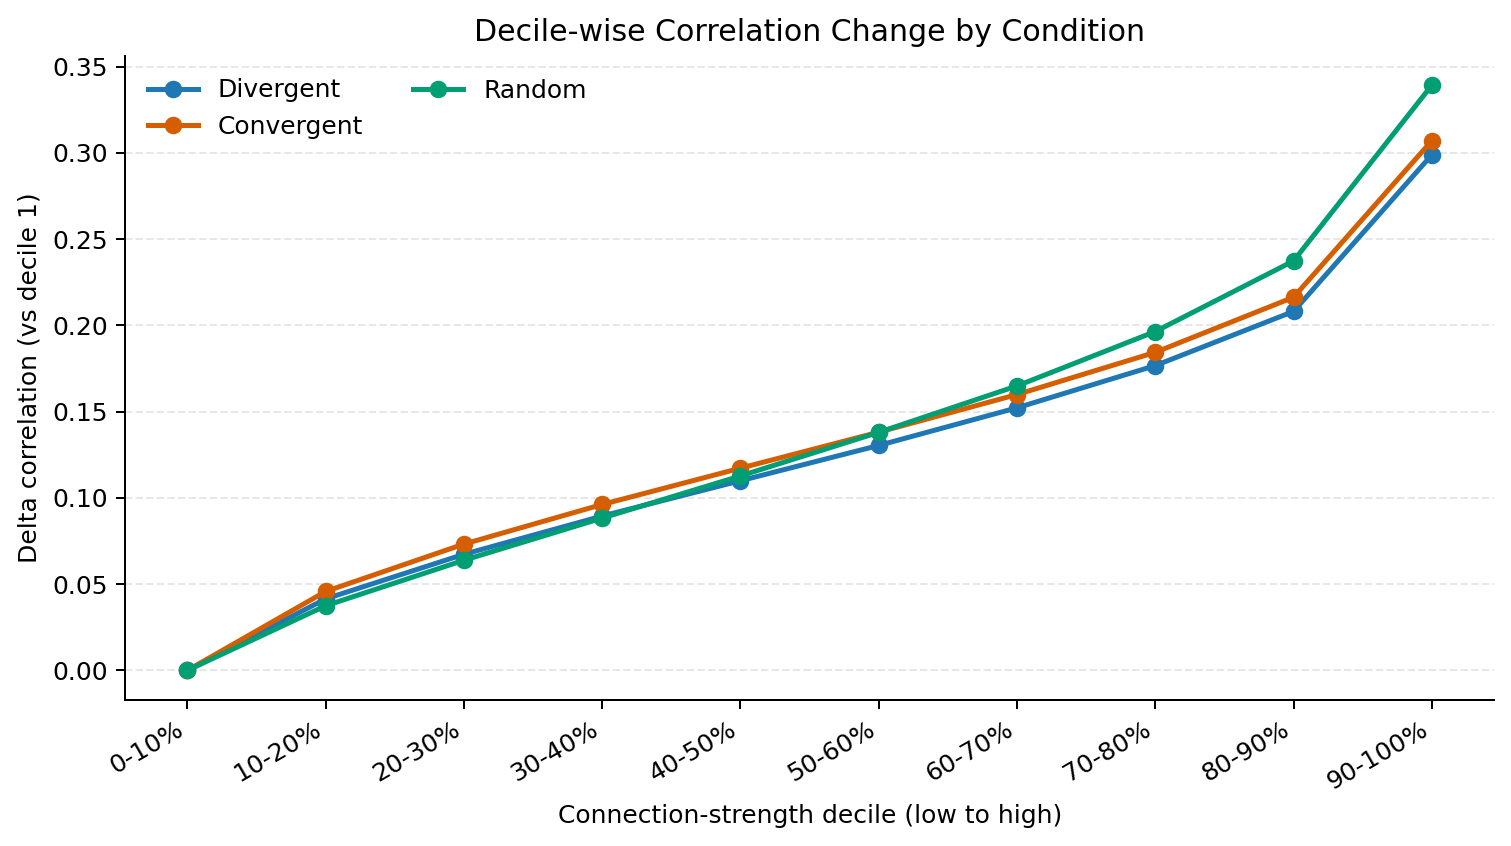

In [60]:

def upper_triangle_values(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix[mask]

corr_rows = []
decile_rows = []
for cls in sorted(nx_result):
    corr_matrix = np.asarray(nx_result[cls]["corr_matrix"], dtype=float)
    offdiag = upper_triangle_values(corr_matrix)
    if offdiag.size == 0:
        continue

    # Split sorted correlation values into 10 equal-count bins (deciles)
    sorted_corr = np.sort(offdiag)
    decile_bins = np.array_split(sorted_corr, 10)

    decile_means = []
    for decile_idx, decile_vals in enumerate(decile_bins, start=1):
        q_low = (decile_idx - 1) / 10
        q_high = decile_idx / 10
        decile_mean = float(np.mean(decile_vals)) if decile_vals.size > 0 else np.nan

        decile_means.append(decile_mean)
        decile_rows.append({
            "Class_ID": cls,
            "Class_Name": label_names.get(cls, str(cls)),
            "Decile_Index": decile_idx,
            "Decile_Label": f"{int(q_low*100)}-{int(q_high*100)}%",
            "Lower_Quantile": q_low,
            "Upper_Quantile": q_high,
            "Pair_Count": int(decile_vals.size),
            "Mean_Correlation": decile_mean,
            "Min_Correlation": float(np.min(decile_vals)) if decile_vals.size > 0 else np.nan,
            "Max_Correlation": float(np.max(decile_vals)) if decile_vals.size > 0 else np.nan,
        })

    weak_mean = decile_means[0]
    strong_mean = decile_means[-1]
    corr_rows.append({
        "Class_ID": cls,
        "Class_Name": label_names.get(cls, str(cls)),
        "Mean_Correlation": float(np.mean(offdiag)),
        "Weak_Correlation_Mean": weak_mean,
        "Strong_Correlation_Mean": strong_mean,
        "Strong_Weak_Gap": strong_mean - weak_mean,
        "Pair_Count": int(offdiag.size),
    })

df_corr_strength = pd.DataFrame(corr_rows)
df_corr_deciles = pd.DataFrame(decile_rows)

# Save decile-level stats for downstream group analysis
decile_csv_path = os.path.join(data_out_dir, "correlation_deciles.csv")
df_corr_deciles.to_csv(decile_csv_path, index=False)
print(f"[*] Decile-level correlation stats saved to: {decile_csv_path}")

# Figure 1: summary view
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=180)
axes[0].bar(
    df_corr_strength["Class_Name"],
    df_corr_strength["Mean_Correlation"],
    color=[class_colors[c] for c in df_corr_strength["Class_ID"]],
    edgecolor="#333333",
)
axes[0].set_ylabel("Mean correlation")
axes[0].set_title("Pairwise Correlation Strength")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

x = np.arange(len(df_corr_strength))
w = 0.34
axes[1].bar(x - w / 2, df_corr_strength["Weak_Correlation_Mean"], width=w, color="#B0BEC5", edgecolor="#333333", label="Weakest 10%")
axes[1].bar(x + w / 2, df_corr_strength["Strong_Correlation_Mean"], width=w, color="#455A64", edgecolor="#333333", label="Strongest 10%")
axes[1].plot(x, df_corr_strength["Strong_Weak_Gap"], color="#D55E00", lw=2.2, marker="o", label="Gap")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_corr_strength["Class_Name"])
axes[1].set_ylabel("Correlation")
axes[1].set_title("Weakest vs Strongest Decile")
axes[1].legend(frameon=False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, "pairwise_correlation.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: decile-wise line comparison (each class is one line)
fig2, ax2 = plt.subplots(figsize=(8.5, 4.8), dpi=180)
for cls in sorted(df_corr_deciles["Class_ID"].unique()):
    sub = df_corr_deciles[df_corr_deciles["Class_ID"] == cls].sort_values("Decile_Index")
    ax2.plot(
        sub["Decile_Index"],
        sub["Mean_Correlation"],
        marker="o",
        lw=2,
        color=class_colors.get(cls, None),
        label=label_names.get(cls, str(cls)),
    )

ax2.set_xticks(np.arange(1, 11))
ax2.set_xticklabels([f"{(i-1)*10}-{i*10}%" for i in range(1, 11)], rotation=30, ha="right")
ax2.set_xlabel("Connection-strength decile (low to high)")
ax2.set_ylabel("Mean correlation")
ax2.set_title("Decile-wise Correlation Comparison")
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.legend(frameon=False, ncol=2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
fig2.tight_layout()
fig2.savefig(os.path.join(fig_out_dir, "pairwise_correlation_deciles_line.png"), dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: condition-wise stratified correlation change relative to the weakest decile
df_corr_deciles_delta = df_corr_deciles.sort_values(["Class_ID", "Decile_Index"]).copy()
df_corr_deciles_delta["Delta_vs_Decile1"] = df_corr_deciles_delta.groupby("Class_ID")["Mean_Correlation"].transform(lambda s: s - s.iloc[0])

fig3, ax3 = plt.subplots(figsize=(8.5, 4.8), dpi=180)
for cls in sorted(df_corr_deciles_delta["Class_ID"].unique()):
    sub = df_corr_deciles_delta[df_corr_deciles_delta["Class_ID"] == cls].sort_values("Decile_Index")
    ax3.plot(
        sub["Decile_Index"],
        sub["Delta_vs_Decile1"],
        marker="o",
        lw=2,
        color=class_colors.get(cls, None),
        label=label_names.get(cls, str(cls)),
    )

ax3.set_xticks(np.arange(1, 11))
ax3.set_xticklabels([f"{(i-1)*10}-{i*10}%" for i in range(1, 11)], rotation=30, ha="right")
ax3.set_xlabel("Connection-strength decile (low to high)")
ax3.set_ylabel("Delta correlation (vs decile 1)")
ax3.set_title("Decile-wise Correlation Change by Condition")
ax3.grid(axis="y", linestyle="--", alpha=0.3)
ax3.legend(frameon=False, ncol=2)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
fig3.tight_layout()
fig3.savefig(os.path.join(fig_out_dir, "pairwise_correlation_deciles_delta.png"), dpi=300, bbox_inches="tight")
plt.show()



## 9.1 Signal vs Noise Correlation Coupling

Following standard definitions in Cohen & Kohn (2011, Nat Neurosci) and Averbeck et al. (2006, Nat Rev Neurosci), this section computes condition-wise signal/noise correlations and their coupling.


[*] Signal-noise pair table saved to: ../results/M73_1128/data/sig_noise_pair_values_by_condition.csv
[*] Signal-noise summary saved to: ../results/M73_1128/data/sig_noise_strength_summary_by_condition.csv


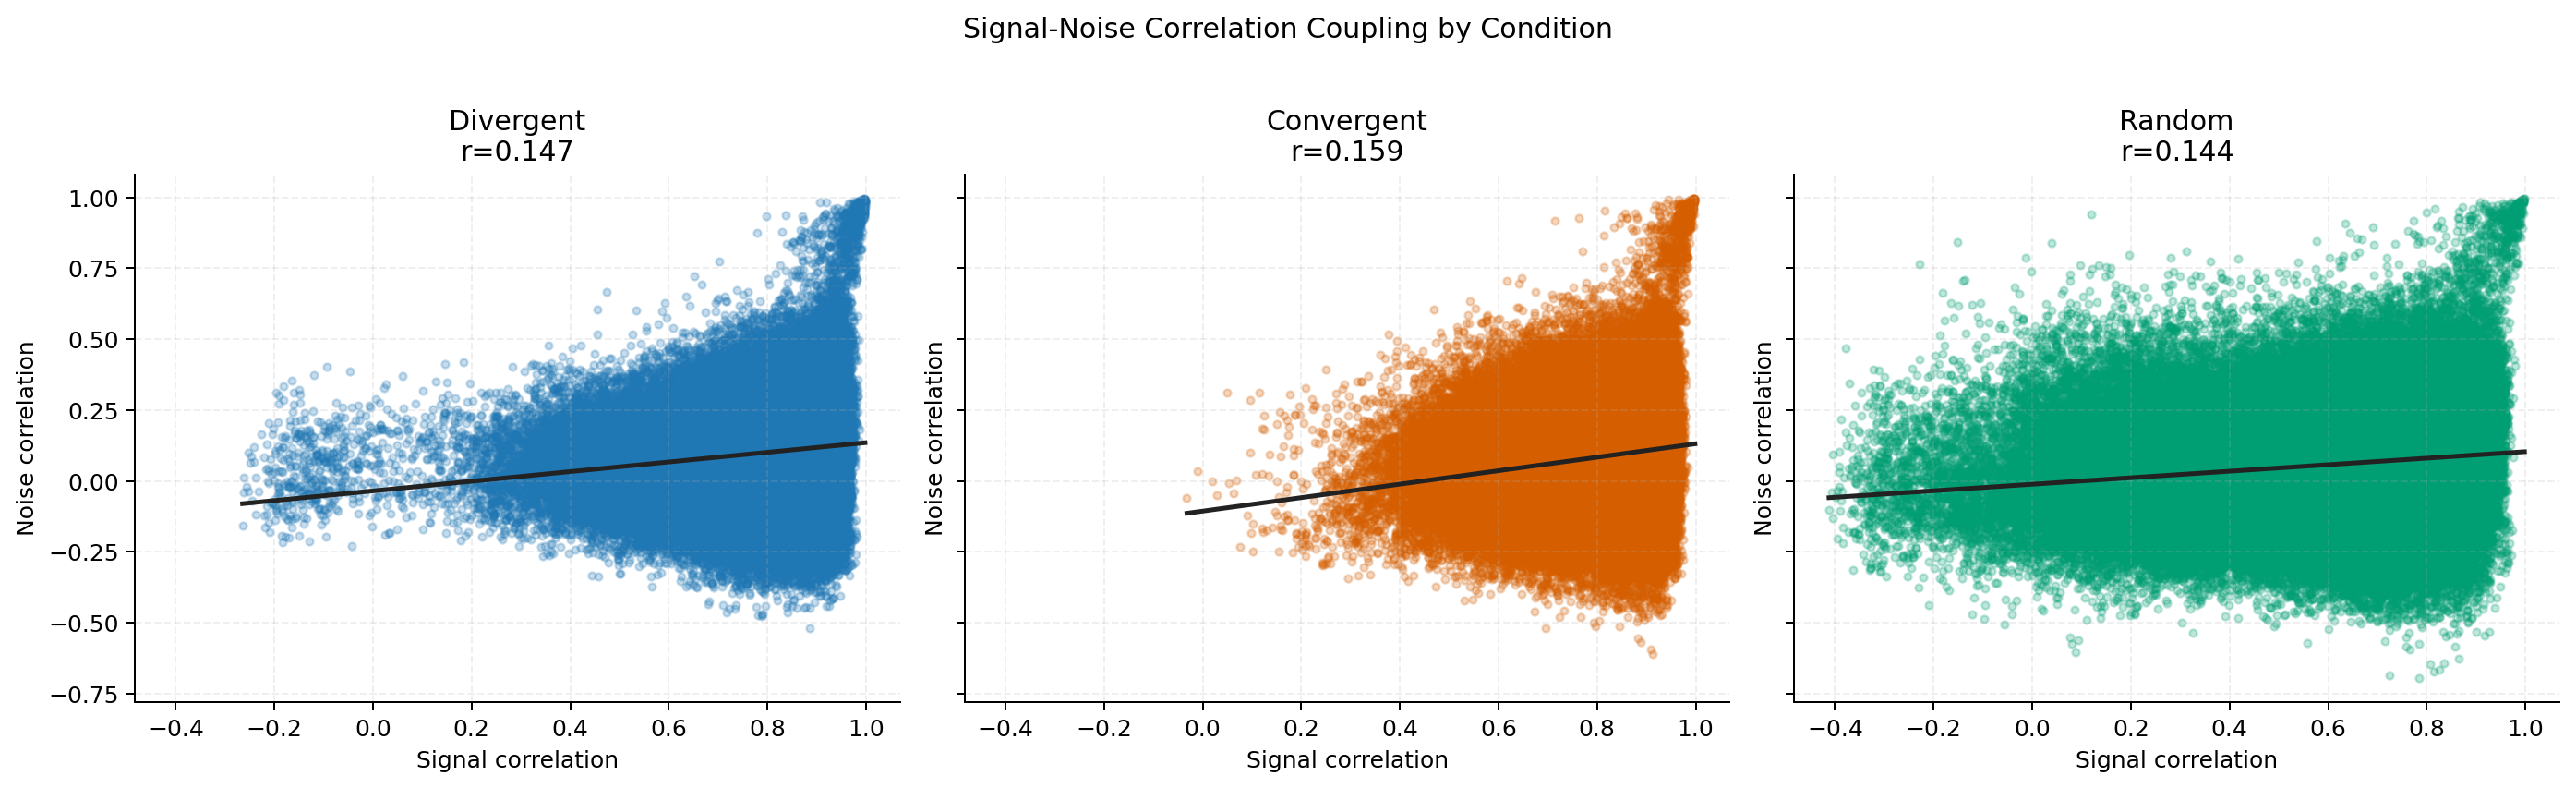

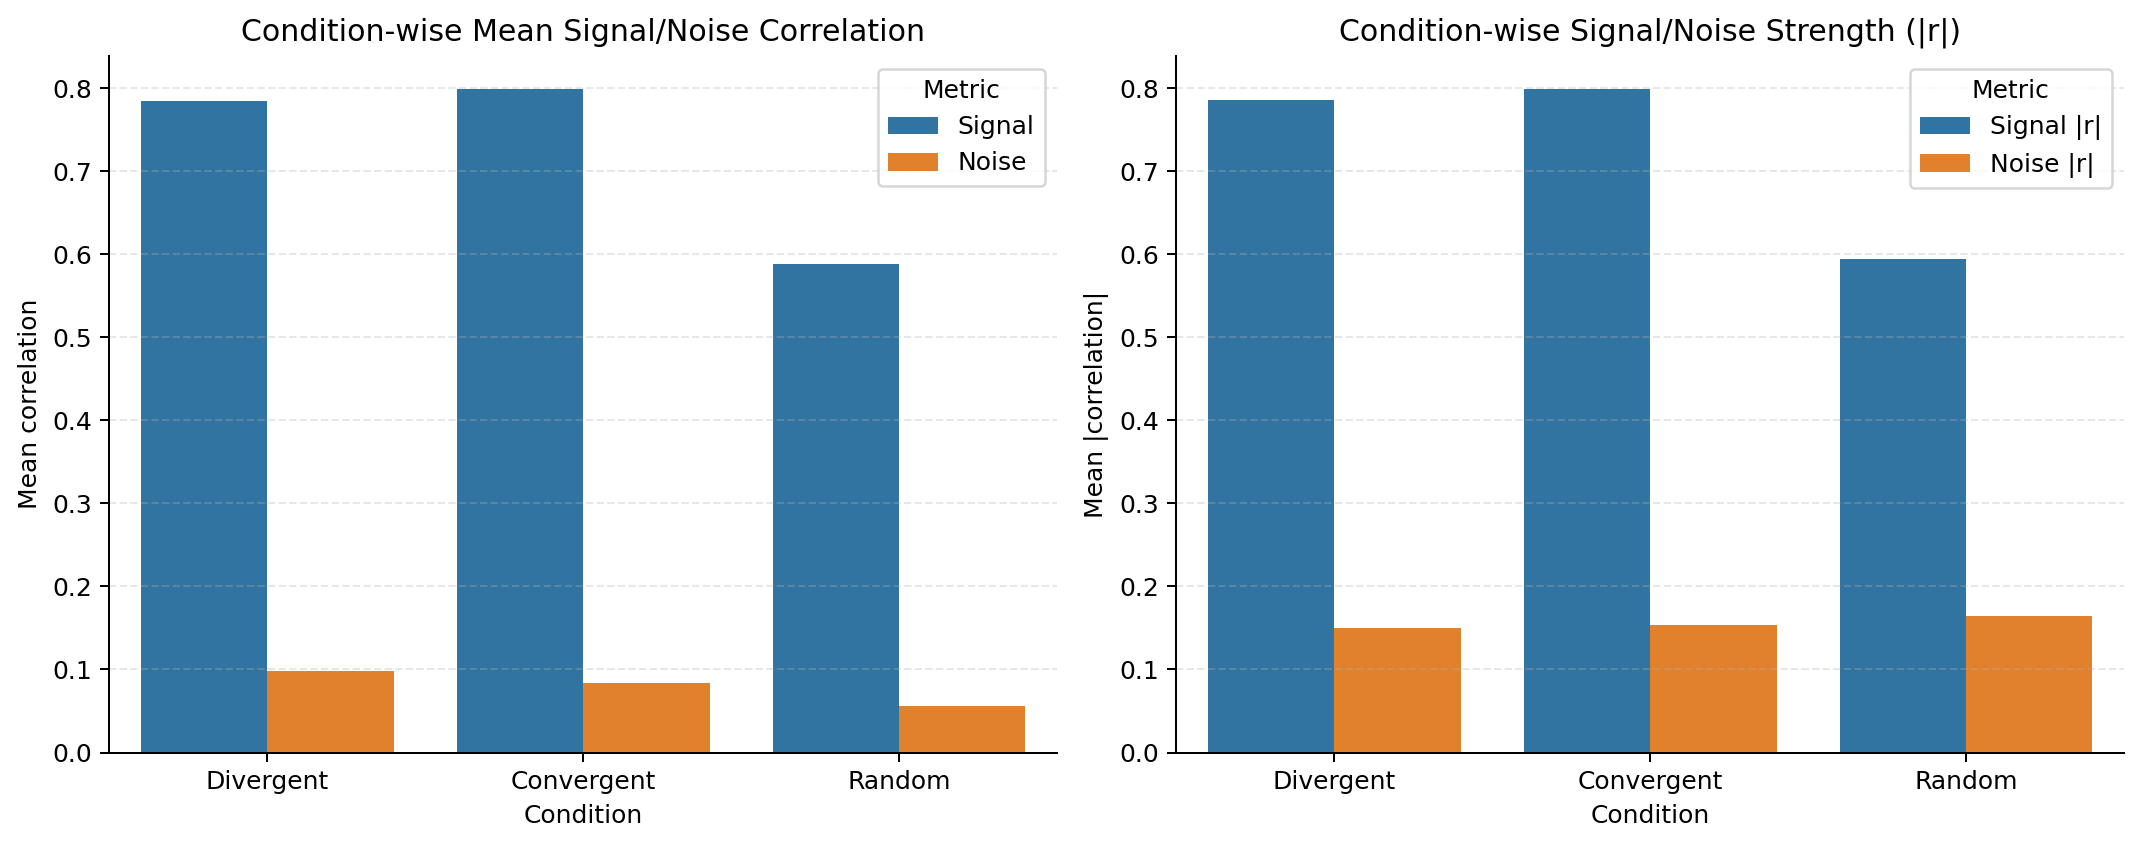

[*] Noise-decile coupling table saved to: ../results/M73_1128/data/noise_corr_decile_coupling.csv


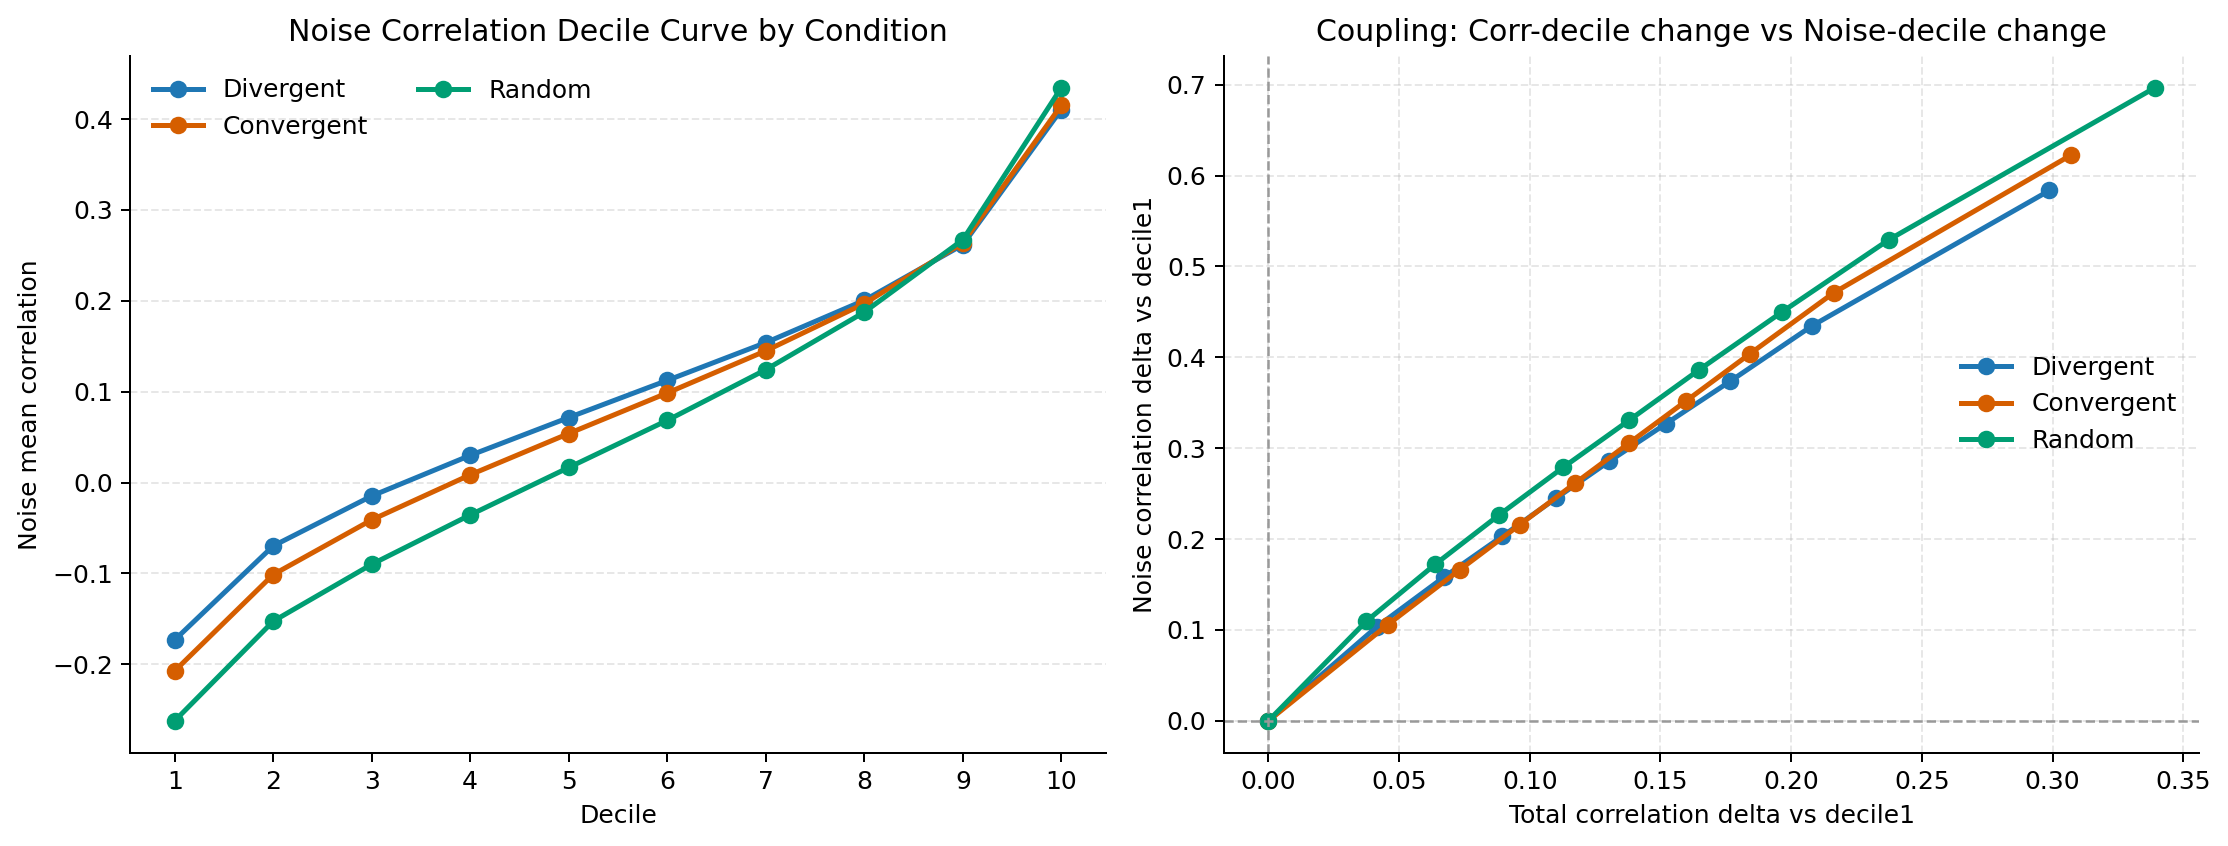

In [61]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Literature-aligned definitions:
# 1) Signal correlation: correlation between mean response features of neuron pairs.
# 2) Noise correlation: correlation of trial-by-trial residual fluctuations under the same condition.
# References: Cohen & Kohn (2011); Averbeck et al. (2006).


def upper_triangle_values_local(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return matrix[mask]


def robust_corrcoef(X, rowvar=False):
    """Safe Pearson correlation matrix with NaN handling."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be 2D")
    if (rowvar and X.shape[1] < 2) or ((not rowvar) and X.shape[0] < 2):
        n = X.shape[0] if rowvar else X.shape[1]
        out = np.full((n, n), np.nan)
        np.fill_diagonal(out, 1.0)
        return out

    C = np.corrcoef(X, rowvar=rowvar)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 1.0)
    return C


# Use spike segments: shape (n_trials, n_neurons, n_time)
X_trials = np.asarray(segments_spi, dtype=float)
y_trials = np.asarray(labels_spi)
classes = sorted(np.unique(y_trials).astype(int).tolist())

# Noise-correlation window (same response window used elsewhere)
noise_window = slice(10, 13)

signal_corr_by_class = {}
noise_corr_by_class = {}
pair_rows = []
summary_rows = []

for cls in classes:
    trials_c = X_trials[y_trials == cls]
    if trials_c.shape[0] < 3:
        print(f"[!] Skip class {cls}: too few trials for noise correlation")
        continue

    # Condition-specific signal features:
    # each neuron's mean temporal response curve under this condition
    mean_time_profile = np.nanmean(trials_c, axis=0)  # (n_neurons, n_time)
    sig_corr = robust_corrcoef(mean_time_profile, rowvar=True)

    # Condition-specific noise features:
    # trial-wise scalar response residuals (same stimulus context)
    trial_resp = np.nanmean(trials_c[:, :, noise_window], axis=2)  # (n_trials, n_neurons)
    residual = trial_resp - np.nanmean(trial_resp, axis=0, keepdims=True)
    noi_corr = robust_corrcoef(residual, rowvar=False)

    signal_corr_by_class[cls] = sig_corr
    noise_corr_by_class[cls] = noi_corr

    sig_vals = upper_triangle_values_local(sig_corr)
    noi_vals = upper_triangle_values_local(noi_corr)

    # Pairwise table for coupling scatter
    n_pairs = min(sig_vals.size, noi_vals.size)
    class_name = label_names.get(cls, str(cls)) if 'label_names' in globals() else str(cls)
    for k in range(n_pairs):
        pair_rows.append({
            'Class_ID': cls,
            'Class_Name': class_name,
            'Signal_Corr': float(sig_vals[k]),
            'Noise_Corr': float(noi_vals[k]),
            'Abs_Signal_Corr': float(abs(sig_vals[k])),
            'Abs_Noise_Corr': float(abs(noi_vals[k])),
        })

    summary_rows.append({
        'Class_ID': cls,
        'Class_Name': class_name,
        'Mean_Signal_Corr': float(np.mean(sig_vals)),
        'Mean_Noise_Corr': float(np.mean(noi_vals)),
        'Mean_Abs_Signal_Corr': float(np.mean(np.abs(sig_vals))),
        'Mean_Abs_Noise_Corr': float(np.mean(np.abs(noi_vals))),
        'Signal_Noise_Coupling_r': float(np.corrcoef(sig_vals, noi_vals)[0, 1]) if sig_vals.size > 1 else np.nan,
    })


df_sig_noise_pairs = pd.DataFrame(pair_rows)
df_sig_noise_strength = pd.DataFrame(summary_rows)

pair_csv = os.path.join(data_out_dir, 'sig_noise_pair_values_by_condition.csv')
summary_csv = os.path.join(data_out_dir, 'sig_noise_strength_summary_by_condition.csv')
df_sig_noise_pairs.to_csv(pair_csv, index=False)
df_sig_noise_strength.to_csv(summary_csv, index=False)
print(f"[*] Signal-noise pair table saved to: {pair_csv}")
print(f"[*] Signal-noise summary saved to: {summary_csv}")

# 1) Condition-wise coupling scatter: signal vs noise
n_cls = len(df_sig_noise_pairs['Class_ID'].unique())
fig, axes = plt.subplots(1, n_cls, figsize=(5.2 * n_cls, 4.6), dpi=180, sharex=True, sharey=True)
if n_cls == 1:
    axes = [axes]

for ax, cls in zip(axes, sorted(df_sig_noise_pairs['Class_ID'].unique())):
    sub = df_sig_noise_pairs[df_sig_noise_pairs['Class_ID'] == cls]
    cname = sub['Class_Name'].iloc[0]
    sns.regplot(
        data=sub,
        x='Signal_Corr',
        y='Noise_Corr',
        scatter_kws={'s': 10, 'alpha': 0.25, 'color': class_colors.get(cls, '#1F77B4')},
        line_kws={'color': '#222222', 'lw': 2},
        ax=ax,
    )
    r_val = np.corrcoef(sub['Signal_Corr'], sub['Noise_Corr'])[0, 1] if len(sub) > 1 else np.nan
    ax.set_title(f"{cname}\nr={r_val:.3f}")
    ax.set_xlabel('Signal correlation')
    ax.set_ylabel('Noise correlation')
    ax.grid(alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Signal-Noise Correlation Coupling by Condition', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, 'signal_noise_coupling_scatter_by_condition.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2) Compare signal/noise strengths across conditions
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.8), dpi=180)

plot_df_raw = df_sig_noise_strength.melt(
    id_vars=['Class_ID', 'Class_Name'],
    value_vars=['Mean_Signal_Corr', 'Mean_Noise_Corr'],
    var_name='Metric',
    value_name='Value',
)
plot_df_raw['Metric'] = plot_df_raw['Metric'].map({'Mean_Signal_Corr': 'Signal', 'Mean_Noise_Corr': 'Noise'})

sns.barplot(data=plot_df_raw, x='Class_Name', y='Value', hue='Metric', ax=axes2[0])
axes2[0].set_title('Condition-wise Mean Signal/Noise Correlation')
axes2[0].set_xlabel('Condition')
axes2[0].set_ylabel('Mean correlation')
axes2[0].grid(axis='y', linestyle='--', alpha=0.3)
axes2[0].spines['top'].set_visible(False)
axes2[0].spines['right'].set_visible(False)

plot_df_abs = df_sig_noise_strength.melt(
    id_vars=['Class_ID', 'Class_Name'],
    value_vars=['Mean_Abs_Signal_Corr', 'Mean_Abs_Noise_Corr'],
    var_name='Metric',
    value_name='Value',
)
plot_df_abs['Metric'] = plot_df_abs['Metric'].map({'Mean_Abs_Signal_Corr': 'Signal |r|', 'Mean_Abs_Noise_Corr': 'Noise |r|'})

sns.barplot(data=plot_df_abs, x='Class_Name', y='Value', hue='Metric', ax=axes2[1])
axes2[1].set_title('Condition-wise Signal/Noise Strength (|r|)')
axes2[1].set_xlabel('Condition')
axes2[1].set_ylabel('Mean |correlation|')
axes2[1].grid(axis='y', linestyle='--', alpha=0.3)
axes2[1].spines['top'].set_visible(False)
axes2[1].spines['right'].set_visible(False)

fig2.tight_layout()
fig2.savefig(os.path.join(fig_out_dir, 'signal_noise_strength_by_condition.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3) Couple condition-wise noise-correlation change with existing decile stratification
noise_decile_rows = []
for cls, Cn in noise_corr_by_class.items():
    vals = np.sort(upper_triangle_values_local(Cn))
    bins = np.array_split(vals, 10)
    for i, b in enumerate(bins, start=1):
        noise_decile_rows.append({
            'Class_ID': cls,
            'Class_Name': label_names.get(cls, str(cls)) if 'label_names' in globals() else str(cls),
            'Decile_Index': i,
            'Noise_Mean_Corr': float(np.mean(b)) if b.size > 0 else np.nan,
        })

df_noise_deciles = pd.DataFrame(noise_decile_rows)

# Merge with existing decile table from section 9
df_decile_coupling = pd.merge(
    df_corr_deciles[['Class_ID', 'Class_Name', 'Decile_Index', 'Mean_Correlation']],
    df_noise_deciles,
    on=['Class_ID', 'Class_Name', 'Decile_Index'],
    how='inner',
)

# Add delta relative to decile1
df_decile_coupling = df_decile_coupling.sort_values(['Class_ID', 'Decile_Index']).copy()
df_decile_coupling['Corr_Delta_vs_D1'] = df_decile_coupling.groupby('Class_ID')['Mean_Correlation'].transform(lambda s: s - s.iloc[0])
df_decile_coupling['Noise_Delta_vs_D1'] = df_decile_coupling.groupby('Class_ID')['Noise_Mean_Corr'].transform(lambda s: s - s.iloc[0])

coupling_csv = os.path.join(data_out_dir, 'noise_corr_decile_coupling.csv')
df_decile_coupling.to_csv(coupling_csv, index=False)
print(f"[*] Noise-decile coupling table saved to: {coupling_csv}")

fig3, axes3 = plt.subplots(1, 2, figsize=(12.5, 4.8), dpi=180)

for cls in sorted(df_decile_coupling['Class_ID'].unique()):
    sub = df_decile_coupling[df_decile_coupling['Class_ID'] == cls].sort_values('Decile_Index')
    axes3[0].plot(
        sub['Decile_Index'],
        sub['Noise_Mean_Corr'],
        marker='o',
        lw=2,
        color=class_colors.get(cls, None),
        label=label_names.get(cls, str(cls)) if 'label_names' in globals() else str(cls),
    )

axes3[0].set_xticks(np.arange(1, 11))
axes3[0].set_title('Noise Correlation Decile Curve by Condition')
axes3[0].set_xlabel('Decile')
axes3[0].set_ylabel('Noise mean correlation')
axes3[0].grid(axis='y', linestyle='--', alpha=0.3)
axes3[0].legend(frameon=False, ncol=2)
axes3[0].spines['top'].set_visible(False)
axes3[0].spines['right'].set_visible(False)

for cls in sorted(df_decile_coupling['Class_ID'].unique()):
    sub = df_decile_coupling[df_decile_coupling['Class_ID'] == cls].sort_values('Decile_Index')
    axes3[1].plot(
        sub['Corr_Delta_vs_D1'],
        sub['Noise_Delta_vs_D1'],
        marker='o',
        lw=2,
        color=class_colors.get(cls, None),
        label=label_names.get(cls, str(cls)) if 'label_names' in globals() else str(cls),
    )

axes3[1].axhline(0, color='#999999', lw=1, ls='--')
axes3[1].axvline(0, color='#999999', lw=1, ls='--')
axes3[1].set_title('Coupling: Corr-decile change vs Noise-decile change')
axes3[1].set_xlabel('Total correlation delta vs decile1')
axes3[1].set_ylabel('Noise correlation delta vs decile1')
axes3[1].grid(axis='both', linestyle='--', alpha=0.3)
axes3[1].legend(frameon=False, ncol=1)
axes3[1].spines['top'].set_visible(False)
axes3[1].spines['right'].set_visible(False)

fig3.tight_layout()
fig3.savefig(os.path.join(fig_out_dir, 'noise_corr_deciles_and_coupling.png'), dpi=300, bbox_inches='tight')
plt.show()




<a id="sec-10"></a>
## 10. Export and Report Generation

Export structured metrics to JSON and generate a Markdown report.


In [62]:
import json
import os
import pandas as pd
from datetime import datetime

def export_mouse_results(mouse_id, df_entropy, df_corr_strength, df_corr_deciles, participants_dict, save_dir, fig_dir):
    """
    Export integrated metrics for one mouse to JSON/CSV and a Markdown report.
    """
    os.makedirs(save_dir, exist_ok=True)

    entropy_records = df_entropy.to_dict(orient='records')
    corr_records = df_corr_strength.to_dict(orient='records')
    corr_decile_records = df_corr_deciles.to_dict(orient='records')

    mouse_data = {
        'mouse_id': mouse_id,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'entropy_metrics': entropy_records,
        'network_correlation': corr_records,
        'network_correlation_deciles': corr_decile_records,
        'rr_participants_ratio': participants_dict,
    }

    json_path = os.path.join(save_dir, f'{mouse_id}_statistics.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(mouse_data, f, indent=4)

    decile_csv_path = os.path.join(save_dir, f'{mouse_id}_correlation_deciles.csv')
    df_corr_deciles.to_csv(decile_csv_path, index=False)

    print(f'[*] Structured statistics saved to: {json_path}')
    print(f'[*] Decile-level correlation data saved to: {decile_csv_path}')

    md_path = os.path.join(save_dir, f'{mouse_id}_analysis_report.md')

    def dicts_to_md_table(dict_list):
        if not dict_list:
            return ''
        headers = list(dict_list[0].keys())
        header_row = '| ' + ' | '.join(headers) + ' |'
        sep_row = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
        rows = []
        for d in dict_list:
            formatted_vals = [f'{v:.4f}' if isinstance(v, float) else str(v) for v in d.values()]
            rows.append('| ' + ' | '.join(formatted_vals) + ' |')
        return '\n'.join([header_row, sep_row] + rows)

    with open(md_path, 'w', encoding='utf-8') as f:
        f.write(f'# Mouse Neural Activity Report - {mouse_id}\n\n')
        f.write(f'**Generated At**: {mouse_data["timestamp"]}\n\n')

        f.write('## 1. RSM and Shannon Entropy\n\n')
        f.write('Metrics for representation stability and variability across stimulus conditions.\n\n')
        f.write(dicts_to_md_table(entropy_records) + '\n\n')

        f.write('## 2. Pairwise Network Correlation Summary\n\n')
        f.write('Difference between lowest and highest correlation tails.\n\n')
        f.write(dicts_to_md_table(corr_records) + '\n\n')

        f.write('## 2.1 Decile-wise Correlation Strength (Every 10%)\n\n')
        f.write('Connectivity values are sorted by raw correlation and split into 10 equal bins.\n\n')
        f.write(dicts_to_md_table(corr_decile_records[:30]) + '\n\n')

        f.write('## 3. RR Participant Ratio\n\n')
        f.write('Response ratio of class-specific RR neurons relative to other RR neurons.\n\n')
        participants_rows = [{'Condition': k, 'Response_Ratio': v} for k, v in participants_dict.items()]
        f.write(dicts_to_md_table(participants_rows) + '\n\n')

        f.write('## 4. Figure Index\n\n')
        f.write('- Preference-sorted heatmap: `./figures/neural_patterns_preference_sorted.png`\n')
        f.write('- Hierarchical clustermap: `./figures/neural_patterns_clustermap.png`\n')
        f.write('- RSM similarity distribution: `./figures/similarity_distribution.png`\n')
        f.write('- Pairwise correlation summary: `./figures/pairwise_correlation.png`\n')
        f.write('- Decile-wise line chart: `./figures/pairwise_correlation_deciles_line.png`\n')

    print(f'[*] Markdown report generated: {md_path}')

# --- Execute export after all analyses ---
current_mouse_id = data_paths[idx]

export_mouse_results(
    mouse_id=current_mouse_id,
    df_entropy=df_entropy,
    df_corr_strength=df_corr_strength,
    df_corr_deciles=df_corr_deciles,
    participants_dict=participants,
    save_dir=data_out_dir,
    fig_dir=fig_out_dir,
)



[*] Structured statistics saved to: ../results/M73_1128/data/M73_1128_statistics.json
[*] Decile-level correlation data saved to: ../results/M73_1128/data/M73_1128_correlation_deciles.csv
[*] Markdown report generated: ../results/M73_1128/data/M73_1128_analysis_report.md


<a id="sec-11"></a>
## 11. Decoder Robustness (Task 1-2)

Generate fixed-window decoder confusion matrix + shuffled baseline (Task1), and Top 10% neuron ablation with random-drop control (Task2).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

# ===== lightweight Task1-2 based on existing analysis =====
n_splits = 3
shuffle_repeats = 40
random_drop_repeats = 20
ablation_ratio = 0.10
random_state = 42

y_all = np.asarray(labels_flo)
segments_all = np.asarray(segments_flo, dtype=float)

# keep stimulus classes only (exclude label 0 if present)
mask = y_all != 0
y = y_all[mask].astype(int)
segments_use = segments_all[mask]
n_time = segments_use.shape[2]

# choose decoder window from existing timepoint-accuracy result when available
if 'accuracies' in globals() and len(np.asarray(accuracies).ravel()) == n_time:
    best_t = int(np.nanargmax(np.asarray(accuracies).ravel()))
else:
    best_t = min(10, n_time - 1)
win_start = max(0, best_t - 1)
win_end = min(n_time, best_t + 2)
if win_end <= win_start:
    win_start = max(0, best_t)
    win_end = min(n_time, win_start + 1)

X = np.nanmean(segments_use[:, :, win_start:win_end], axis=2)

def build_model():
    return Pipeline([
        ('scaler', RobustScaler()),
        ('svc', SVC(kernel='rbf', class_weight='balanced', C=1.0, gamma='scale')),
    ])

def cv_accuracy_with_pred(X_mat, y_vec, n_splits=3, random_state=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_pred = np.empty_like(y_vec)
    fold_acc = []
    for tr_idx, te_idx in cv.split(X_mat, y_vec):
        model = build_model()
        model.fit(X_mat[tr_idx], y_vec[tr_idx])
        pred = model.predict(X_mat[te_idx])
        y_pred[te_idx] = pred
        fold_acc.append(float((pred == y_vec[te_idx]).mean()))
    fold_acc = np.asarray(fold_acc, dtype=float)
    return float(fold_acc.mean()), float(fold_acc.std(ddof=1)), y_pred

# ---------- Task1: decoder summary + confusion matrix ----------
full_acc, full_std, y_pred = cv_accuracy_with_pred(X, y, n_splits=n_splits, random_state=random_state)

rng = np.random.default_rng(random_state)
shuffle_acc = []
for rep in range(shuffle_repeats):
    y_shuf = rng.permutation(y)
    acc_shuf, _, _ = cv_accuracy_with_pred(
        X, y_shuf, n_splits=n_splits, random_state=random_state + 100 + rep
    )
    shuffle_acc.append(acc_shuf)
shuffle_acc = np.asarray(shuffle_acc, dtype=float)

classes = np.sort(np.unique(y))
class_names = [label_names.get(int(c), str(c)) if 'label_names' in globals() else str(c) for c in classes]
cm_norm = confusion_matrix(y, y_pred, labels=classes, normalize='true')
cm_raw = confusion_matrix(y, y_pred, labels=classes, normalize=None)

fig, ax = plt.subplots(figsize=(6.0, 5.0), dpi=180)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
ax.set_title(
    f'Task1 Decoder Confusion Matrix (window {win_start}:{win_end})\\n'
    f'Acc={full_acc:.3f}±{full_std:.3f} | Shuffle={shuffle_acc.mean():.3f}±{shuffle_acc.std(ddof=1):.3f}'
)
fig.tight_layout()
task1_fig = os.path.join(fig_out_dir, 'decoder_confusion_matrix.png')
fig.savefig(task1_fig, dpi=300, bbox_inches='tight')
plt.close(fig)

task1_summary = pd.DataFrame([
    {
        'window_start': int(win_start),
        'window_end': int(win_end),
        'n_trials': int(X.shape[0]),
        'n_neurons': int(X.shape[1]),
        'n_splits': int(n_splits),
        'accuracy_mean': float(full_acc),
        'accuracy_std': float(full_std),
        'shuffle_accuracy_mean': float(shuffle_acc.mean()),
        'shuffle_accuracy_std': float(shuffle_acc.std(ddof=1)),
        'accuracy_minus_shuffle': float(full_acc - shuffle_acc.mean()),
    }
])
for idx, cname in enumerate(class_names):
    task1_summary[f'recall_{cname}'] = float(cm_norm[idx, idx])
task1_csv = os.path.join(data_out_dir, 'decoder_summary.csv')
task1_summary.to_csv(task1_csv, index=False)
pd.DataFrame(cm_raw, index=class_names, columns=class_names).to_csv(
    os.path.join(data_out_dir, 'decoder_confusion_matrix.csv')
)

# ---------- Task2: Top10% ablation + random-drop control ----------
n_neurons = X.shape[1]
n_remove = max(1, int(np.ceil(n_neurons * ablation_ratio)))
neuron_mean_resp = np.nanmean(X, axis=0)
top_idx = np.argsort(neuron_mean_resp)[::-1][:n_remove]

keep_mask = np.ones(n_neurons, dtype=bool)
keep_mask[top_idx] = False
X_ablate = X[:, keep_mask]
ablate_acc, ablate_std, _ = cv_accuracy_with_pred(
    X_ablate, y, n_splits=n_splits, random_state=random_state + 500
)

rand_acc = []
for rep in range(random_drop_repeats):
    drop_idx = rng.choice(n_neurons, size=n_remove, replace=False)
    keep_rand = np.ones(n_neurons, dtype=bool)
    keep_rand[drop_idx] = False
    acc_rand, _, _ = cv_accuracy_with_pred(
        X[:, keep_rand], y, n_splits=n_splits, random_state=random_state + 800 + rep
    )
    rand_acc.append(acc_rand)
rand_acc = np.asarray(rand_acc, dtype=float)

task2_summary = pd.DataFrame([
    {
        'window_start': int(win_start),
        'window_end': int(win_end),
        'n_trials': int(X.shape[0]),
        'n_neurons_total': int(n_neurons),
        'n_neurons_removed': int(n_remove),
        'removed_ratio': float(n_remove / n_neurons),
        'full_accuracy_mean': float(full_acc),
        'full_accuracy_std': float(full_std),
        'top10_ablation_accuracy_mean': float(ablate_acc),
        'top10_ablation_accuracy_std': float(ablate_std),
        'random_drop_mean_accuracy': float(rand_acc.mean()),
        'random_drop_std_accuracy': float(rand_acc.std(ddof=1)),
        'delta_full_minus_top10': float(full_acc - ablate_acc),
        'delta_top10_minus_random_mean': float(ablate_acc - rand_acc.mean()),
        'ablation_rank_in_random': float((rand_acc <= ablate_acc).mean()),
    }
])
task2_csv = os.path.join(data_out_dir, 'decoder_ablation_summary.csv')
task2_summary.to_csv(task2_csv, index=False)
pd.DataFrame({'repeat_idx': np.arange(rand_acc.size), 'accuracy_mean': rand_acc}).to_csv(
    os.path.join(data_out_dir, 'decoder_random_drop_repeats.csv'),
    index=False
)

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=180)
labels_bar = ['Full model', 'Top10% ablation', 'Random drop\\n(mean±sd)']
means = [full_acc, ablate_acc, float(rand_acc.mean())]
errs = [full_std, ablate_std, float(rand_acc.std(ddof=1))]
colors = ['#4C78A8', '#F58518', '#54A24B']
x = np.arange(3)
ax.bar(x, means, yerr=errs, color=colors, alpha=0.85, capsize=4, edgecolor='#333333')
jitter = rng.uniform(-0.14, 0.14, size=rand_acc.size)
ax.scatter(np.full(rand_acc.size, x[2]) + jitter, rand_acc, s=18, alpha=0.55, color='#2E7D32')
chance = 1.0 / classes.size
ax.axhline(chance, color='#777777', linestyle='--', linewidth=1.2, label=f'Chance={chance:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Cross-validated accuracy')
ax.set_title(
    f'Task2 Top10% Neuron Ablation (random repeats={random_drop_repeats})\\n'
    f'Δ(full-top10)={full_acc - ablate_acc:.3f} | Δ(top10-rand)={ablate_acc - rand_acc.mean():.3f}'
)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
task2_fig = os.path.join(fig_out_dir, 'decoder_ablation_top10.png')
fig.savefig(task2_fig, dpi=300, bbox_inches='tight')
plt.close(fig)

decoder_task12_outputs = {
    'decoder_summary_csv': task1_csv,
    'decoder_confusion_fig': task1_fig,
    'decoder_ablation_summary_csv': task2_csv,
    'decoder_ablation_fig': task2_fig,
}
print('[*] Task1 summary:', task1_csv)
print('[*] Task1 confusion fig:', task1_fig)
print('[*] Task2 summary:', task2_csv)
print('[*] Task2 ablation fig:', task2_fig)
decoder_task12_outputs
